In [18]:
import os
import pandas as pd
import logging
import numpy as np
from sklearn.feature_selection import VarianceThreshold
import matplotlib.pyplot as plt
import seaborn as sns



In [19]:
df_main = pd.read_csv('../data/raw/accidents_with_weather.csv',low_memory=False)
print(f"Loaded shape: {df_main.shape}")

Loaded shape: (48472, 65)


## setting up logging

In [7]:
logging.basicConfig(
    filename='../reports/cleaning_log.log',
    level=logging.INFO,
    format='%(asctime)s - %(message)s'
)

cleaning_log = []
quarantine_records = []

def log_action(step, rule, records_affected, action, rationale):
    entry = {
        'step': step,
        'rule': rule,
        'records_affected': records_affected,
        'action': action,
        'rationale': rationale
    }
    cleaning_log.append(entry)
    logging.info(f"{step} | {rule} | {records_affected} records | {action} | {rationale}")
    print(f"{step}: {action} ({records_affected} records) - {rationale}")

def quarantine(df_main, mask, reason):
    rejected = df_main[mask].copy()
    rejected['rejection_reason'] = reason
    quarantine_records.append(rejected)
    log_action('Accuracy', reason, len(rejected), 'Reject → Quarantine', 'Critical field violation')
    return df_main[~mask].copy()

## dropping unwanted columns (as stated with reasons in the report of phase 1)

In [8]:
df_main.columns

Index(['collision_index', 'collision_year', 'collision_ref_no',
       'location_easting_osgr', 'location_northing_osgr', 'longitude',
       'latitude', 'police_force', 'collision_severity', 'number_of_vehicles',
       'number_of_casualties', 'date', 'day_of_week', 'time',
       'local_authority_district', 'local_authority_ons_district',
       'local_authority_highway', 'local_authority_highway_current',
       'first_road_class', 'first_road_number', 'road_type', 'speed_limit',
       'junction_detail_historic', 'junction_detail', 'junction_control',
       'second_road_class', 'second_road_number',
       'pedestrian_crossing_human_control_historic',
       'pedestrian_crossing_physical_facilities_historic',
       'pedestrian_crossing', 'light_conditions', 'weather_conditions',
       'road_surface_conditions', 'special_conditions_at_site',
       'carriageway_hazards_historic', 'carriageway_hazards',
       'urban_or_rural_area', 'did_police_officer_attend_scene_of_accident',
 

In [9]:
def drop_columns(df):
    cols_to_drop = [
        'collision_index', 'collision_ref_no', 'collision_year',
        'location_easting_osgr', 'location_northing_osgr',
        'local_authority_district', 'local_authority_ons_district','local_authority_highway','local_authority_highway_current', 
        'lsoa_of_accident_location',
        'first_road_number', 'second_road_number',
        'junction_detail_historic', 'pedestrian_crossing_human_control_historic',
        'pedestrian_crossing_physical_facilities_historic', 'carriageway_hazards_historic',
        'enhanced_severity_collision', 'collision_injury_based',
        'collision_adjusted_severity_serious','collision_adjusted_severity_slight',
        'trunk_road_flag', 'police_force','datetime_local',
       'datetime_utc_x', '_lat_r', '_lon_r', 'datetime_utc_merge','datetime_utc_y',
        '_lat_r', '_lon_r', 'accident_hour','date'
    ]
    return df.drop(columns=[c for c in cols_to_drop if c in df.columns])

In [10]:
df_main = drop_columns(df_main)
df_main.shape

(48472, 35)

### (48472, 35) -> still more than 10 features

In [11]:
numerical_cols = [
    'longitude',
    'latitude',
    'number_of_vehicles',
    'number_of_casualties',
    'wx_temperature_2m',
    'wx_relative_humidity_2m',
    'wx_precipitation',
    'wx_rain',
    'wx_snowfall',
    'wx_snow_depth',
    'wx_wind_speed_10m',
    'wx_wind_direction_10m',
    'wx_wind_gusts_10m',
    'wx_visibility',
    'wx_surface_pressure',
    'wx_cloud_cover',
]

target_col = 'collision_severity'

categorical_cols = [
    'day_of_week',
    'speed_limit',
    'time',
    'first_road_class',
    'road_type',
    'junction_detail',
    'junction_control',
    'second_road_class',
    'pedestrian_crossing',
    'light_conditions',
    'weather_conditions',
    'road_surface_conditions',
    'special_conditions_at_site',
    'carriageway_hazards',
    'urban_or_rural_area',
    'did_police_officer_attend_scene_of_accident',
    'wx_weather_code',
    'wx_is_day']


In [12]:
for col in categorical_cols:
    if df_main[col].dtype in ['int64', 'int32', 'float64']:
        df_main[col] = df_main[col].astype('category')

In [47]:
# plt.figure(figsize=(8,6))

# plt.scatter(
#     df_main['longitude'],
#     df_main['latitude'],
#     c=df_main['collision_severity'],
#     cmap='Reds',   
#     alpha=0.6
# )

# plt.colorbar(label='Collision Severity')
# plt.xlabel('Longitude')
# plt.ylabel('Latitude')
# plt.title('Accident Locations Colored by Severity')

# plt.show()

In [48]:
df_main.columns

Index(['longitude', 'latitude', 'collision_severity', 'number_of_vehicles',
       'number_of_casualties', 'day_of_week', 'time', 'first_road_class',
       'road_type', 'speed_limit', 'junction_detail', 'junction_control',
       'second_road_class', 'pedestrian_crossing', 'light_conditions',
       'weather_conditions', 'road_surface_conditions',
       'special_conditions_at_site', 'carriageway_hazards',
       'urban_or_rural_area', 'did_police_officer_attend_scene_of_accident',
       'wx_temperature_2m', 'wx_relative_humidity_2m', 'wx_precipitation',
       'wx_rain', 'wx_snowfall', 'wx_snow_depth', 'wx_weather_code',
       'wx_wind_speed_10m', 'wx_wind_direction_10m', 'wx_wind_gusts_10m',
       'wx_visibility', 'wx_surface_pressure', 'wx_cloud_cover', 'wx_is_day'],
      dtype='str')

# Accuracy: Reject Impossible Values

In [49]:
mask = (df_main['latitude'] < 49) | (df_main['latitude'] > 61) | (df_main['longitude'] < -11) | (df_main['longitude'] > 2)
df_main = quarantine(df_main, mask, 'latitude/longitude outside UK bounds')

mask = (df_main['number_of_vehicles'] <= 0) | (df_main['number_of_casualties'] <= 0)
df_main = quarantine(df_main, mask, 'number_of_vehicles or number_of_casualties <= 0')

Accuracy: Reject → Quarantine (0 records) - Critical field violation
Accuracy: Reject → Quarantine (0 records) - Critical field violation


---------------------------------------------------------------------------------------------------

# Consistency: Standardize Codes & Types

# !Big Note i assumed that the 'unkown's arent missing

In [50]:
coded_missing = {
    'speed_limit': [-1],
    'junction_detail': [-1],
    'junction_control': [-1],
    'second_road_class': [-1],
    'pedestrian_crossing': [-1],
    'special_conditions_at_site': [-1],
    'carriageway_hazards': [-1],
    'light_conditions': [-1],
    'weather_conditions': [-1],
    'road_surface_conditions': [-1],
    'did_police_officer_attend_scene_of_accident': [-1]
}

for col, codes in coded_missing.items():
    if col in df_main.columns:
        count = df_main[col].isin(codes).sum()
        df_main[col] = df_main[col].replace(codes, np.nan)
        log_action('Consistency', f'{col} coded as {codes}', count, 'Replace with NaN', 'Standardize missing value representation')

df_main['time'] = pd.to_datetime(df_main['time'], format='%H:%M', errors='coerce').dt.time
log_action('Consistency', 'date/time format', len(df_main), 'Coerce to datetime', 'Standardize temporal format')

Consistency: Replace with NaN (185 records) - Standardize missing value representation
Consistency: Replace with NaN (5410 records) - Standardize missing value representation
Consistency: Replace with NaN (21093 records) - Standardize missing value representation
Consistency: Replace with NaN (6215 records) - Standardize missing value representation
Consistency: Replace with NaN (928 records) - Standardize missing value representation
Consistency: Replace with NaN (31898 records) - Standardize missing value representation
Consistency: Replace with NaN (918 records) - Standardize missing value representation
Consistency: Replace with NaN (307 records) - Standardize missing value representation
Consistency: Replace with NaN (422 records) - Standardize missing value representation
Consistency: Replace with NaN (922 records) - Standardize missing value representation
Consistency: Replace with NaN (609 records) - Standardize missing value representation
Consistency: Coerce to datetime (4847

---------------------------------------------------------------------------------------------------

# Completeness 

### the plan:
latitude/longitude <5% missing -> MCAR -> Row deletion  
speed_limit <1% missing -> MCAR -> Row deletion 
wx_visibility = 100% missing -> Column deletion  
special_conditions_at_site: 31898 missing > 50% -> Column deletion  
junction_control : 21093 missing > 40% -> Column deletion  
5%< Numerical & skewed <20% -> Median imputation  
5%< Categorical <20% -> Median imputation  

In [13]:
count = df_main[['latitude', 'longitude','speed_limit']].isnull().any(axis=1).sum()
df_main = df_main.dropna(subset=['latitude', 'longitude','speed_limit'])
log_action('Completeness', 'latitude/longitude missing', count, 'Row deletion', '<5% missing, MCAR pattern')

if 'wx_visibility' in df_main.columns:
    df_main = df_main.drop(columns=['wx_visibility'])
    numerical_cols.remove('wx_visibility')
    log_action('Completeness', 'wx_visibility all missing', len(df_main), 'Column deletion', '100% missing, cannot impute')

if 'special_conditions_at_site' in df_main.columns:
    df_main = df_main.drop(columns=['special_conditions_at_site'])
    categorical_cols.remove('special_conditions_at_site')
    log_action('Completeness', 'special_conditions_at_site > 50', len(df_main), 'Column deletion', '>50% missing, cannot impute')

if 'junction_control' in df_main.columns:
    df_main = df_main.drop(columns=['junction_control'])
    categorical_cols.remove('junction_control')
    log_action('Completeness', 'junction_control > 40', len(df_main), 'Column deletion', '>40% missing, cannot impute')



Completeness: Row deletion (1 records) - <5% missing, MCAR pattern
Completeness: Column deletion (48471 records) - 100% missing, cannot impute
Completeness: Column deletion (48471 records) - >50% missing, cannot impute
Completeness: Column deletion (48471 records) - >40% missing, cannot impute


## splitting the data before doing any other operations

In [14]:
from sklearn.model_selection import train_test_split
X = df_main.copy()
X = X.drop(columns=['collision_severity'])
y = df_main.copy()[target_col]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

df = pd.concat([X_train, y_train], axis=1)

In [20]:
df

,longitude,latitude,number_of_vehicles,number_of_casualties,day_of_week,time,first_road_class,road_type,speed_limit,junction_detail,...,wx_snowfall,wx_snow_depth,wx_weather_code,wx_wind_speed_10m,wx_wind_direction_10m,wx_wind_gusts_10m,wx_surface_pressure,wx_cloud_cover,wx_is_day,collision_severity
12073,-2.96027,53.39422,1,1,5,12:55,6,6,30,13,...,0.0,0.00,0.0,19.023878,147.362500,44.280000,1008.80000,8.0,1.0,3
10557,-2.29113,53.69899,1,1,7,11:12,3,3,70,0,...,0.0,0.01,3.0,11.656998,193.392520,25.199999,1003.54470,100.0,1.0,3
44148,-1.85228,51.41420,2,2,2,14:03,3,6,60,19,...,0.0,0.00,3.0,18.470840,74.744830,36.000000,1003.38385,100.0,1.0,3
46966,-4.21055,55.82831,1,1,5,14:10,3,6,20,17,...,0.0,0.00,0.0,4.873315,175.763690,14.040000,1022.12510,0.0,1.0,3
3830,-0.11957,51.51634,1,1,2,01:46,3,6,20,16,...,0.0,0.00,51.0,10.404249,37.266483,21.960000,1026.18930,78.0,0.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4144,-0.15841,51.53515,2,1,7,10:52,6,6,20,0,...,0.0,0.00,3.0,9.195868,130.236280,23.759998,997.64703,100.0,1.0,3
10313,-2.74723,54.66564,1,1,1,09:30,6,6,30,13,...,0.0,0.00,3.0,18.466455,173.844920,34.200000,1008.30786,100.0,1.0,3
45083,-2.27779,50.91557,2,3,7,20:21,3,6,60,0,...,0.0,0.00,0.0,21.171244,63.217170,34.920000,1008.03625,0.0,0.0,2
31564,-0.39711,51.61932,1,1,5,18:00,6,6,30,13,...,0.0,0.00,3.0,24.408424,217.208000,52.920000,1005.24090,100.0,0.0,3


In [16]:
df_test = pd.concat([X_test, y_test], axis=1)
df_test.dropna(inplace=True)

In [17]:
X_test = df_test.drop(columns=[target_col])
y_test = df_test[target_col]

In [56]:
# numerical_cols imputation (median)
for col in numerical_cols:
    if col in df.columns and df[col].isnull().sum() > 0:
        count = df[col].isnull().sum()
        df[col] = df[col].fillna(df[col].median())
        log_action('Completeness', f'{col} missing', count, 'Median imputation', 'Skewed distribution, robust to outliers')

# categorical_cols imputation (mode)

for col in categorical_cols:
    if col in df.columns and df[col].isnull().sum() > 0:
        count = df[col].isnull().sum()
        df[col] = df[col].fillna(df[col].mode()[0])
        log_action('Completeness', f'{col} missing <20%', count, 'Mode imputation', 'Clear dominant category')

Completeness: Median imputation (105 records) - Skewed distribution, robust to outliers
Completeness: Median imputation (105 records) - Skewed distribution, robust to outliers
Completeness: Median imputation (105 records) - Skewed distribution, robust to outliers
Completeness: Median imputation (105 records) - Skewed distribution, robust to outliers
Completeness: Median imputation (105 records) - Skewed distribution, robust to outliers
Completeness: Median imputation (114 records) - Skewed distribution, robust to outliers
Completeness: Median imputation (105 records) - Skewed distribution, robust to outliers
Completeness: Median imputation (105 records) - Skewed distribution, robust to outliers
Completeness: Median imputation (105 records) - Skewed distribution, robust to outliers
Completeness: Median imputation (105 records) - Skewed distribution, robust to outliers
Completeness: Median imputation (105 records) - Skewed distribution, robust to outliers
Completeness: Mode imputation (4

In [57]:
print(df[df['wx_rain']>0]['wx_rain'])
wx_rain_non_zeros = df[df['wx_rain']>0]['wx_rain']


42492    0.1
46050    0.4
26710    1.3
28966    0.3
1866     0.6
        ... 
40149    0.1
20187    0.1
10429    0.1
19582    0.1
34316    0.2
Name: wx_rain, Length: 5404, dtype: float64


----------------------------------------------------------------------------------------

# Uniqueness: Passed

---------------------------------------------------------------------------

# Outliers

before hundling outliers we noticed something:

In [58]:
print(df[df['number_of_casualties']>1]['number_of_casualties'])
print(df['number_of_casualties'].unique())
print(df['number_of_casualties'].quantile(0.98))

31075    2
473      2
26731    3
26710    3
44362    2
        ..
11400    2
41708    2
20187    2
23768    2
26153    3
Name: number_of_casualties, Length: 6939, dtype: int64
[  1   2   3   4   5   6   7   8  10 142  12  20  18   9  22]
3.0


we find that the dominant vlue is 1 and it has a few values so we will make it categorical with ranges to better represent the data

In [59]:
# numerical_cols.remove('number_of_casualties')

In [60]:
# bins = [0, 2, 5, np.inf]
# # (0<x<2) ->1 
# # (2<x<5) ->2
# # (5<x) ->3 
# labels = [1, 2, 3]
# df['number_of_casualties'] = pd.cut(df['number_of_casualties'], bins=bins, labels=labels, right=False)

In [61]:
df['number_of_casualties']

42492    1
26508    1
6735     1
12045    1
46050    1
        ..
11010    1
7588     1
24870    1
38418    1
30000    1
Name: number_of_casualties, Length: 38628, dtype: int64

In [62]:
# categorical_cols.append('number_of_casualties')

## applying capping

In [63]:
import pandas as pd

DOMINANT_THRESHOLD = 0.3
OUTLIER_RATIO_THRESHOLD = 0.001

def handle_mode_heavy(df, col, dominant_val):
    non_dom_mask = df[col] != dominant_val
    non_dom_vals = df.loc[non_dom_mask, col]

    if len(non_dom_vals) < 10:
        log_action('Outliers', f'{col} mode-heavy ({dominant_val})', len(non_dom_vals), 
                   'Skipped', 'Insufficient non-dominant samples')
        return df

    lower = non_dom_vals.quantile(0.05)
    upper = non_dom_vals.quantile(0.95)
    # print(lower)
    # print(upper)

    outlier_mask = (non_dom_vals < lower) | (non_dom_vals > upper)
    if outlier_mask.sum() == 0:
        return df

    full_outlier_mask = outlier_mask.reindex(df.index, fill_value=False).astype(bool)
    count = full_outlier_mask.sum()

    if count > OUTLIER_RATIO_THRESHOLD * len(df):
        clipped = non_dom_vals.clip(lower=lower, upper=upper)
        
        if pd.api.types.is_integer_dtype(df[col]) and (clipped % 1).any():
            df[col] = df[col].astype(float)
            
        df.loc[non_dom_mask, col] = clipped
        log_action('Outliers', f'{col} mode-heavy ({dominant_val}) IQR', count, 
                   'Capping', f'Non-dominant values capped, dominant={dominant_val} col:{col}')
    else:
        df = df[~full_outlier_mask].copy()
        log_action('Outliers', f'{col} mode-heavy ({dominant_val}) IQR', count, 
                   'Removal', f'Non-dominant outliers removed, dominant={dominant_val} col:{col}')

    return df


def outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    if IQR == 0:
        return df

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_mask = (df[col] < lower) | (df[col] > upper)
    count = outlier_mask.sum()

    if count == 0:
        return df

    if count > OUTLIER_RATIO_THRESHOLD * len(df):
        clipped = df[col].clip(lower=lower, upper=upper)
        if pd.api.types.is_integer_dtype(df[col]) and (clipped % 1).any():
            df[col] = df[col].astype(float)
        df[col] = clipped
        log_action('Outliers', f'{col} IQR bounds', count, 'Capping', 
                   f'Preserve dataset size, reduce outlier influence, col:{col}')
    else:
        df = df[~outlier_mask].copy()
        log_action('Outliers', f'{col} IQR bounds', count, 'Removal', 
                   f'Confirmed errors, col:{col}')

    return df


def process_outliers(df, col):
    valid_col = df[col].dropna()
    if len(valid_col) == 0:
        return df
        
    mode_vals = valid_col.mode()
    dominant_val = mode_vals.iloc[0]
    dominant_ratio = (df[col] == dominant_val).mean()

    if dominant_ratio > DOMINANT_THRESHOLD:
        return handle_mode_heavy(df, col, dominant_val)
    else:
        return outliers_iqr(df, col)


for col in list(set(numerical_cols)-set({'longitude','latitude'})):
    df = process_outliers(df, col)

Outliers: Capping (251 records) - Non-dominant values capped, dominant=0.0 col:wx_precipitation
Outliers: Capping (249 records) - Non-dominant values capped, dominant=2 col:number_of_vehicles
Outliers: Removal (3 records) - Confirmed errors, col:wx_relative_humidity_2m
Outliers: Capping (953 records) - Preserve dataset size, reduce outlier influence, col:wx_surface_pressure
Outliers: Removal (12 records) - Non-dominant outliers removed, dominant=0.0 col:wx_snowfall
Outliers: Capping (396 records) - Preserve dataset size, reduce outlier influence, col:wx_wind_gusts_10m
Outliers: Capping (56 records) - Preserve dataset size, reduce outlier influence, col:wx_temperature_2m
Outliers: Capping (608 records) - Preserve dataset size, reduce outlier influence, col:wx_wind_speed_10m
Outliers: Capping (266 records) - Non-dominant values capped, dominant=0.0 col:wx_rain
Outliers: Capping (1053 records) - Non-dominant values capped, dominant=100.0 col:wx_cloud_cover
Outliers: Capping (210 records) 

In [64]:
print(df[df['wx_rain']>0]['wx_rain'])

42492    0.1
46050    0.4
26710    1.3
28966    0.3
1866     0.6
        ... 
40149    0.1
20187    0.1
10429    0.1
19582    0.1
34316    0.2
Name: wx_rain, Length: 5395, dtype: float64


In [65]:
df

,longitude,latitude,number_of_vehicles,number_of_casualties,day_of_week,time,first_road_class,road_type,speed_limit,junction_detail,...,wx_snowfall,wx_snow_depth,wx_weather_code,wx_wind_speed_10m,wx_wind_direction_10m,wx_wind_gusts_10m,wx_surface_pressure,wx_cloud_cover,wx_is_day,collision_severity
42492,-5.36183,50.20714,1,1,3,08:50:00,3,6,60,0,...,0.0,0.0,51.0,19.633205,267.898380,35.640000,1017.10310,100.0,1.0,3
26508,-1.24074,53.16960,2,1,5,21:47:00,3,6,30,0,...,0.0,0.0,3.0,21.898684,231.340160,45.360000,1005.73895,100.0,1.0,1
6735,-0.24063,51.53766,2,1,4,16:57:00,6,6,30,13,...,0.0,0.0,3.0,17.194475,30.860834,43.199997,1019.11005,100.0,1.0,3
12045,-2.63703,53.47527,2,1,6,06:22:00,3,6,30,13,...,0.0,0.0,0.0,1.207477,63.435013,5.400000,1024.66300,4.0,0.0,3
46050,-3.80229,51.66543,1,1,3,09:21:00,6,6,20,0,...,0.0,0.0,51.0,11.085720,237.600170,28.080000,981.33484,100.0,1.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11010,-2.73910,53.77960,1,1,1,16:45:00,4,6,30,0,...,0.0,0.0,0.0,15.639297,78.043440,30.239998,997.45197,2.0,1.0,3
7588,-0.13933,51.45500,2,1,5,12:40:00,5,6,20,16,...,0.0,0.0,3.0,10.152064,52.926850,29.160000,1019.44160,100.0,1.0,3
24870,-1.53478,52.28785,2,1,2,16:21:00,4,6,30,0,...,0.0,0.0,1.0,24.316660,267.878940,53.280000,1006.88960,37.0,1.0,3
38418,0.26288,51.11587,2,1,5,22:00:00,6,6,30,0,...,0.0,0.0,0.0,7.452086,322.853240,11.159999,1011.40540,0.0,0.0,3


# Feature Engineering 

In [66]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from category_encoders import BinaryEncoder

## Feature Transformation
  
converting the collision_severity do that 3 in the most sever not the opposite

In [67]:
df['collision_severity']=4-df['collision_severity']
y_test = 4-y_test

## Feature Interactions

In [68]:
# Arithmetic Complications
df['casualties_per_vehicle'] = df['number_of_casualties'] / (df['number_of_vehicles'] + 1) 
df['rain_intensity'] = df['wx_rain'] * df['wx_precipitation']
df['wind_force'] = df['wx_wind_speed_10m'] * df['wx_wind_gusts_10m']

df['visibility_risk'] = (
    (df['wx_cloud_cover'] / 100) * 0.4 +
    (df['wx_precipitation'] > 0).astype(int) * 0.4 +
    (df['weather_conditions'] == 7).astype(int) * 0.2 
)
numerical_cols.extend([
    'casualties_per_vehicle','rain_intensity','wind_force','visibility_risk'])

X_test['casualties_per_vehicle'] = X_test['number_of_casualties'] / (X_test['number_of_vehicles'] + 1) 
X_test['rain_intensity'] = X_test['wx_rain'] * X_test['wx_precipitation']
X_test['wind_force'] = X_test['wx_wind_speed_10m'] * X_test['wx_wind_gusts_10m']

X_test['visibility_risk'] = (
    (X_test['wx_cloud_cover'] / 100) * 0.4 +
    (X_test['wx_precipitation'] > 0).astype(int) * 0.4 +
    (X_test['weather_conditions'] == 7).astype(int) * 0.2 
)

In [69]:
df[df['wind_force']>0]

,longitude,latitude,number_of_vehicles,number_of_casualties,day_of_week,time,first_road_class,road_type,speed_limit,junction_detail,...,wx_wind_direction_10m,wx_wind_gusts_10m,wx_surface_pressure,wx_cloud_cover,wx_is_day,collision_severity,casualties_per_vehicle,rain_intensity,wind_force,visibility_risk
42492,-5.36183,50.20714,1,1,3,08:50:00,3,6,60,0,...,267.898380,35.640000,1017.10310,100.0,1.0,1,0.500000,0.01,699.727426,0.800
26508,-1.24074,53.16960,2,1,5,21:47:00,3,6,30,0,...,231.340160,45.360000,1005.73895,100.0,1.0,3,0.333333,0.00,993.324306,0.400
6735,-0.24063,51.53766,2,1,4,16:57:00,6,6,30,13,...,30.860834,43.199997,1019.11005,100.0,1.0,1,0.333333,0.00,742.801268,0.400
12045,-2.63703,53.47527,2,1,6,06:22:00,3,6,30,13,...,63.435013,5.400000,1024.66300,4.0,0.0,1,0.333333,0.00,6.520374,0.016
46050,-3.80229,51.66543,1,1,3,09:21:00,6,6,20,0,...,237.600170,28.080000,981.33484,100.0,1.0,1,0.500000,0.16,311.287018,0.800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11010,-2.73910,53.77960,1,1,1,16:45:00,4,6,30,0,...,78.043440,30.239998,997.45197,2.0,1.0,1,0.500000,0.00,472.932310,0.008
7588,-0.13933,51.45500,2,1,5,12:40:00,5,6,20,16,...,52.926850,29.160000,1019.44160,100.0,1.0,1,0.333333,0.00,296.034186,0.400
24870,-1.53478,52.28785,2,1,2,16:21:00,4,6,30,0,...,267.878940,53.280000,1006.88960,37.0,1.0,1,0.333333,0.00,1295.591645,0.148
38418,0.26288,51.11587,2,1,5,22:00:00,6,6,30,0,...,322.853240,11.159999,1011.40540,0.0,0.0,1,0.333333,0.00,83.165277,0.000


In [70]:
df[df['rain_intensity']>0]

,longitude,latitude,number_of_vehicles,number_of_casualties,day_of_week,time,first_road_class,road_type,speed_limit,junction_detail,...,wx_wind_direction_10m,wx_wind_gusts_10m,wx_surface_pressure,wx_cloud_cover,wx_is_day,collision_severity,casualties_per_vehicle,rain_intensity,wind_force,visibility_risk
42492,-5.36183,50.20714,1,1,3,08:50:00,3,6,60,0,...,267.898380,35.640000,1017.10310,100.0,1.0,1,0.500000,0.01,699.727426,0.800
46050,-3.80229,51.66543,1,1,3,09:21:00,6,6,20,0,...,237.600170,28.080000,981.33484,100.0,1.0,1,0.500000,0.16,311.287018,0.800
26710,-0.04230,52.95298,2,3,1,22:17:00,4,6,40,13,...,195.592880,41.399998,977.98200,100.0,0.0,2,1.000000,1.69,998.039398,0.800
28966,-0.28575,52.58830,2,1,5,13:55:00,6,1,40,0,...,1.169115,39.239998,1001.65240,60.0,1.0,1,0.333333,0.12,692.337693,0.640
1866,0.17373,51.45201,1,1,6,17:30:00,3,2,30,13,...,68.552200,38.519997,1019.89570,100.0,0.0,1,0.500000,0.36,625.754886,0.800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40149,-0.22785,51.09789,2,1,4,10:28:00,3,3,50,0,...,199.573210,51.480000,1003.99830,100.0,1.0,1,0.333333,0.01,1327.684644,0.800
20187,-0.21940,53.85115,2,2,5,19:45:00,6,6,60,19,...,243.763350,54.360000,1011.13760,91.0,1.0,3,0.666667,0.01,1527.212671,0.764
10429,-2.98608,54.95514,2,1,3,12:02:00,6,6,60,16,...,224.427120,50.399998,1020.81274,100.0,1.0,2,0.333333,0.01,1283.038646,0.800
19582,-0.43159,53.75390,1,1,2,16:55:00,6,3,40,16,...,223.567960,18.720000,1014.52520,100.0,1.0,2,0.500000,0.01,190.672916,0.800


In [71]:
# df[df['casualties_per_vehicle']>0]

In [72]:
df[df['visibility_risk']>0]

,longitude,latitude,number_of_vehicles,number_of_casualties,day_of_week,time,first_road_class,road_type,speed_limit,junction_detail,...,wx_wind_direction_10m,wx_wind_gusts_10m,wx_surface_pressure,wx_cloud_cover,wx_is_day,collision_severity,casualties_per_vehicle,rain_intensity,wind_force,visibility_risk
42492,-5.36183,50.20714,1,1,3,08:50:00,3,6,60,0,...,267.898380,35.640000,1017.10310,100.0,1.0,1,0.500000,0.01,699.727426,0.800
26508,-1.24074,53.16960,2,1,5,21:47:00,3,6,30,0,...,231.340160,45.360000,1005.73895,100.0,1.0,3,0.333333,0.00,993.324306,0.400
6735,-0.24063,51.53766,2,1,4,16:57:00,6,6,30,13,...,30.860834,43.199997,1019.11005,100.0,1.0,1,0.333333,0.00,742.801268,0.400
12045,-2.63703,53.47527,2,1,6,06:22:00,3,6,30,13,...,63.435013,5.400000,1024.66300,4.0,0.0,1,0.333333,0.00,6.520374,0.016
46050,-3.80229,51.66543,1,1,3,09:21:00,6,6,20,0,...,237.600170,28.080000,981.33484,100.0,1.0,1,0.500000,0.16,311.287018,0.800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26153,-1.25159,52.95534,2,3,6,18:32:00,3,6,50,0,...,109.259384,32.039997,995.66420,100.0,1.0,2,1.000000,0.00,507.054580,0.400
34316,-0.89217,51.79622,3,1,6,09:21:00,3,6,50,13,...,274.197570,34.200000,1000.63830,100.0,1.0,1,0.250000,0.04,672.808768,0.800
11010,-2.73910,53.77960,1,1,1,16:45:00,4,6,30,0,...,78.043440,30.239998,997.45197,2.0,1.0,1,0.500000,0.00,472.932310,0.008
7588,-0.13933,51.45500,2,1,5,12:40:00,5,6,20,16,...,52.926850,29.160000,1019.44160,100.0,1.0,1,0.333333,0.00,296.034186,0.400


In [73]:
# # Statistical Aggregations
# df['location_risk'] = df.groupby(['latitude','longitude'])['collision_severity'].transform('mean')
# df['road_severity_mean'] = df.groupby('road_type')['collision_severity'].transform('mean')
# df['weather_severity_mean'] = df.groupby('weather_conditions')['collision_severity'].transform('mean')
# numerical_cols.extend(['location_risk','road_severity_mean','weather_severity_mean'])

In [74]:
# Boolean and Logical Combinations
df['is_bad_weather'] = (
    (df['wx_rain'] > 0) |
    (df['wx_wind_speed_10m'] > 20) |
    (df['wx_wind_gusts_10m'] > 20)
).astype(int)

X_test['is_bad_weather'] = (
    (X_test['wx_rain'] > 0) |
    (X_test['wx_wind_speed_10m'] > 20) |
    (X_test['wx_wind_gusts_10m'] > 20)
).astype(int)


categorical_cols.append('is_bad_weather')

In [75]:
df[df['is_bad_weather']>0]

,longitude,latitude,number_of_vehicles,number_of_casualties,day_of_week,time,first_road_class,road_type,speed_limit,junction_detail,...,wx_wind_gusts_10m,wx_surface_pressure,wx_cloud_cover,wx_is_day,collision_severity,casualties_per_vehicle,rain_intensity,wind_force,visibility_risk,is_bad_weather
42492,-5.36183,50.20714,1,1,3,08:50:00,3,6,60,0,...,35.640000,1017.10310,100.0,1.0,1,0.500000,0.01,699.727426,0.800,1
26508,-1.24074,53.16960,2,1,5,21:47:00,3,6,30,0,...,45.360000,1005.73895,100.0,1.0,3,0.333333,0.00,993.324306,0.400,1
6735,-0.24063,51.53766,2,1,4,16:57:00,6,6,30,13,...,43.199997,1019.11005,100.0,1.0,1,0.333333,0.00,742.801268,0.400,1
46050,-3.80229,51.66543,1,1,3,09:21:00,6,6,20,0,...,28.080000,981.33484,100.0,1.0,1,0.500000,0.16,311.287018,0.800,1
11606,-2.64371,53.74201,2,1,4,14:15:00,6,6,30,0,...,39.960000,1002.79490,43.0,1.0,1,0.333333,0.00,722.437919,0.172,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30761,0.94578,52.05338,2,1,5,19:55:00,3,6,60,13,...,30.599998,1006.19540,0.0,1.0,1,0.333333,0.00,473.047021,0.000,1
11010,-2.73910,53.77960,1,1,1,16:45:00,4,6,30,0,...,30.239998,997.45197,2.0,1.0,1,0.500000,0.00,472.932310,0.008,1
7588,-0.13933,51.45500,2,1,5,12:40:00,5,6,20,16,...,29.160000,1019.44160,100.0,1.0,1,0.333333,0.00,296.034186,0.400,1
24870,-1.53478,52.28785,2,1,2,16:21:00,4,6,30,0,...,53.280000,1006.88960,37.0,1.0,1,0.333333,0.00,1295.591645,0.148,1


In [76]:
df.columns

Index(['longitude', 'latitude', 'number_of_vehicles', 'number_of_casualties',
       'day_of_week', 'time', 'first_road_class', 'road_type', 'speed_limit',
       'junction_detail', 'second_road_class', 'pedestrian_crossing',
       'light_conditions', 'weather_conditions', 'road_surface_conditions',
       'carriageway_hazards', 'urban_or_rural_area',
       'did_police_officer_attend_scene_of_accident', 'wx_temperature_2m',
       'wx_relative_humidity_2m', 'wx_precipitation', 'wx_rain', 'wx_snowfall',
       'wx_snow_depth', 'wx_weather_code', 'wx_wind_speed_10m',
       'wx_wind_direction_10m', 'wx_wind_gusts_10m', 'wx_surface_pressure',
       'wx_cloud_cover', 'wx_is_day', 'collision_severity',
       'casualties_per_vehicle', 'rain_intensity', 'wind_force',
       'visibility_risk', 'is_bad_weather'],
      dtype='str')

## Feature Selection

In [77]:
# # Variance Threshold
# # Lesa msheltesh el columns f3lan h3mel kda b3del EDA
# selector = VarianceThreshold(threshold=0.01)

# df_num = df[numerical_cols]
# df_num_selected = selector.fit_transform(df_num)

# selected_num_cols = df_num.columns[selector.get_support()]
# removed_cols = list(set(numerical_cols) - set(selected_num_cols))
# df = df.drop(columns=removed_cols)

# print("Removed features:", removed_cols)
# print("Kept numerical:", len(list(selected_num_cols)))
# print("All numerical:", len(list(numerical_cols)))
# numerical_cols = list(set(numerical_cols) - set(removed_cols))

In [78]:
# # Correlation Based
# # Lesa msheltesh el columns f3lan h3mel kda b3del EDA
# corr_matrix = df[numerical_cols].corr().abs()


# upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# correlated_pairs = []

# for col in upper.columns:
#     for row in upper.index:
#         if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > 0.9:
#             correlated_pairs.append((row, col, upper.loc[row, col]))


# for a, b, val in correlated_pairs:
#     print(f"{a}  <-->  {b}   | corr = {val:.3f}")
# removed_from_correlation_based = ['wx_rain','wx_precipitation','wx_wind_speed_10m','wx_wind_gusts_10m']
# numerical_cols = list(set(numerical_cols) - set(removed_from_correlation_based))
# df=df.drop(columns=removed_from_correlation_based)

In [79]:
df['rain_intensity']

42492    0.01
26508    0.00
6735     0.00
12045    0.00
46050    0.16
         ... 
11010    0.00
7588     0.00
24870    0.00
38418    0.00
30000    0.00
Name: rain_intensity, Length: 38589, dtype: float64

## Feature Scaling & encoding

using RobustScaler to the heavely skewed features and std for the rest

In [80]:
numerical_cols

['longitude',
 'latitude',
 'number_of_vehicles',
 'number_of_casualties',
 'wx_temperature_2m',
 'wx_relative_humidity_2m',
 'wx_precipitation',
 'wx_rain',
 'wx_snowfall',
 'wx_snow_depth',
 'wx_wind_speed_10m',
 'wx_wind_direction_10m',
 'wx_wind_gusts_10m',
 'wx_surface_pressure',
 'wx_cloud_cover',
 'casualties_per_vehicle',
 'rain_intensity',
 'wind_force',
 'visibility_risk']

In [81]:
df

,longitude,latitude,number_of_vehicles,number_of_casualties,day_of_week,time,first_road_class,road_type,speed_limit,junction_detail,...,wx_wind_gusts_10m,wx_surface_pressure,wx_cloud_cover,wx_is_day,collision_severity,casualties_per_vehicle,rain_intensity,wind_force,visibility_risk,is_bad_weather
42492,-5.36183,50.20714,1,1,3,08:50:00,3,6,60,0,...,35.640000,1017.10310,100.0,1.0,1,0.500000,0.01,699.727426,0.800,1
26508,-1.24074,53.16960,2,1,5,21:47:00,3,6,30,0,...,45.360000,1005.73895,100.0,1.0,3,0.333333,0.00,993.324306,0.400,1
6735,-0.24063,51.53766,2,1,4,16:57:00,6,6,30,13,...,43.199997,1019.11005,100.0,1.0,1,0.333333,0.00,742.801268,0.400,1
12045,-2.63703,53.47527,2,1,6,06:22:00,3,6,30,13,...,5.400000,1024.66300,4.0,0.0,1,0.333333,0.00,6.520374,0.016,0
46050,-3.80229,51.66543,1,1,3,09:21:00,6,6,20,0,...,28.080000,981.33484,100.0,1.0,1,0.500000,0.16,311.287018,0.800,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11010,-2.73910,53.77960,1,1,1,16:45:00,4,6,30,0,...,30.239998,997.45197,2.0,1.0,1,0.500000,0.00,472.932310,0.008,1
7588,-0.13933,51.45500,2,1,5,12:40:00,5,6,20,16,...,29.160000,1019.44160,100.0,1.0,1,0.333333,0.00,296.034186,0.400,1
24870,-1.53478,52.28785,2,1,2,16:21:00,4,6,30,0,...,53.280000,1006.88960,37.0,1.0,1,0.333333,0.00,1295.591645,0.148,1
38418,0.26288,51.11587,2,1,5,22:00:00,6,6,30,0,...,11.159999,1011.40540,0.0,0.0,1,0.333333,0.00,83.165277,0.000,0


In [82]:
robust_col = [ # men el report
    'number_of_vehicles',  
    'number_of_casualties', 
    'rain_intensity' 
]
std_col = list(set(numerical_cols) - set(robust_col))

X_train = df.drop(columns=[target_col])
y_train = df[target_col]

preprocessor1 = ColumnTransformer(
    transformers=[
        ('rob', RobustScaler(), robust_col),
        ('std', StandardScaler(), std_col)
    ],
    remainder='passthrough'
)

preprocessor2 = ColumnTransformer(
    transformers=[
        ('rob', RobustScaler(), robust_col),
        ('std', StandardScaler(), std_col),
        ('cat', BinaryEncoder(handle_unknown='value'), categorical_cols)
    ],
    remainder='passthrough',
    verbose_feature_names_out=True
)

preprocessor1.set_output(transform="pandas")
preprocessor2.set_output(transform="pandas")

X_train_scaled = preprocessor1.fit_transform(X_train)
X_train_scaled_encode = preprocessor2.fit_transform(X_train)

X_train_scaled.columns = [
    col.split('__')[1] if '__' in col else col 
    for col in X_train_scaled.columns
]

X_train_scaled_encode.columns = [
    col.split('__')[1] if '__' in col else col 
    for col in X_train_scaled_encode.columns
]

# #nashael el donia we naa5aly X_train_ haya el final
# X_train_ = X_train_scaled_encode

X_test = preprocessor2.transform(X_test) #data leackage

X_test.columns = [
    col.split('__')[1] if '__' in col else col 
    for col in X_test.columns
]

In [83]:
#nagm3hom le df_ lel sohola bas
df_scaled = pd.concat([X_train_scaled, y_train], axis=1)
df_ = pd.concat([X_train_scaled_encode, y_train], axis=1)

In [84]:
X_train_scaled_encode['number_of_vehicles'].isnull().sum()

np.int64(0)

In [85]:
df_.columns

Index(['number_of_vehicles', 'number_of_casualties', 'rain_intensity',
       'wind_force', 'casualties_per_vehicle', 'wx_wind_speed_10m', 'wx_rain',
       'wx_cloud_cover', 'wx_wind_direction_10m', 'visibility_risk',
       'longitude', 'wx_precipitation', 'wx_relative_humidity_2m', 'latitude',
       'wx_surface_pressure', 'wx_snowfall', 'wx_wind_gusts_10m',
       'wx_temperature_2m', 'wx_snow_depth', 'day_of_week_0', 'day_of_week_1',
       'day_of_week_2', 'speed_limit_0', 'speed_limit_1', 'speed_limit_2',
       'time_0', 'time_1', 'time_2', 'time_3', 'time_4', 'time_5', 'time_6',
       'time_7', 'time_8', 'time_9', 'time_10', 'first_road_class_0',
       'first_road_class_1', 'first_road_class_2', 'road_type_0',
       'road_type_1', 'road_type_2', 'junction_detail_0', 'junction_detail_1',
       'junction_detail_2', 'second_road_class_0', 'second_road_class_1',
       'second_road_class_2', 'second_road_class_3', 'pedestrian_crossing_0',
       'pedestrian_crossing_1', 'pedes

In [86]:
df_scaled

,number_of_vehicles,number_of_casualties,rain_intensity,wind_force,casualties_per_vehicle,wx_wind_speed_10m,wx_rain,wx_cloud_cover,wx_wind_direction_10m,visibility_risk,...,light_conditions,weather_conditions,road_surface_conditions,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,wx_weather_code,wx_is_day,is_bad_weather,collision_severity
42492,-1.0,0.0,0.01,0.505526,0.194687,0.919455,0.218394,0.981911,1.026117,2.059711,...,1,1,1,0,2,1,51.0,1.0,1,1
26508,0.0,0.0,0.00,1.194664,-0.589314,1.259596,-0.252528,0.981911,0.640845,0.437013,...,4,1,1,0,1,3,3.0,1.0,1,3
6735,0.0,0.0,0.00,0.606630,-0.589314,0.553303,-0.252528,0.981911,-1.471924,0.437013,...,1,1,1,0,1,1,3.0,1.0,1,1
12045,0.0,0.0,0.00,-1.121589,-0.589314,-1.846998,-0.252528,-1.302829,-1.128638,-1.120778,...,1,1,1,0,2,1,0.0,0.0,0,1
46050,-1.0,0.0,0.16,-0.406232,0.194687,-0.363871,1.631160,0.981911,0.706816,2.059711,...,1,2,2,0,1,1,51.0,1.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11010,-1.0,0.0,0.00,-0.026814,0.194687,0.319807,-0.252528,-1.350428,-0.974686,-1.153232,...,1,1,1,0,1,2,0.0,1.0,1,1
7588,0.0,0.0,0.00,-0.442034,-0.589314,-0.504050,-0.252528,0.981911,-1.239379,0.437013,...,1,1,1,0,1,1,3.0,1.0,1,1
24870,0.0,0.0,0.00,1.904155,-0.589314,1.622633,-0.252528,-0.517450,1.025912,-0.585288,...,1,1,1,0,1,1,1.0,1.0,1,1
38418,0.0,0.0,0.00,-0.941686,-0.589314,-0.909427,-0.252528,-1.398027,1.605263,-1.185686,...,6,1,1,0,1,1,0.0,0.0,0,1


In [87]:
print(set(df.columns)==set(df_scaled.columns))

True


In [88]:
df_.columns

Index(['number_of_vehicles', 'number_of_casualties', 'rain_intensity',
       'wind_force', 'casualties_per_vehicle', 'wx_wind_speed_10m', 'wx_rain',
       'wx_cloud_cover', 'wx_wind_direction_10m', 'visibility_risk',
       'longitude', 'wx_precipitation', 'wx_relative_humidity_2m', 'latitude',
       'wx_surface_pressure', 'wx_snowfall', 'wx_wind_gusts_10m',
       'wx_temperature_2m', 'wx_snow_depth', 'day_of_week_0', 'day_of_week_1',
       'day_of_week_2', 'speed_limit_0', 'speed_limit_1', 'speed_limit_2',
       'time_0', 'time_1', 'time_2', 'time_3', 'time_4', 'time_5', 'time_6',
       'time_7', 'time_8', 'time_9', 'time_10', 'first_road_class_0',
       'first_road_class_1', 'first_road_class_2', 'road_type_0',
       'road_type_1', 'road_type_2', 'junction_detail_0', 'junction_detail_1',
       'junction_detail_2', 'second_road_class_0', 'second_road_class_1',
       'second_road_class_2', 'second_road_class_3', 'pedestrian_crossing_0',
       'pedestrian_crossing_1', 'pedes

In [89]:
df_scaled.columns

Index(['number_of_vehicles', 'number_of_casualties', 'rain_intensity',
       'wind_force', 'casualties_per_vehicle', 'wx_wind_speed_10m', 'wx_rain',
       'wx_cloud_cover', 'wx_wind_direction_10m', 'visibility_risk',
       'longitude', 'wx_precipitation', 'wx_relative_humidity_2m', 'latitude',
       'wx_surface_pressure', 'wx_snowfall', 'wx_wind_gusts_10m',
       'wx_temperature_2m', 'wx_snow_depth', 'day_of_week', 'time',
       'first_road_class', 'road_type', 'speed_limit', 'junction_detail',
       'second_road_class', 'pedestrian_crossing', 'light_conditions',
       'weather_conditions', 'road_surface_conditions', 'carriageway_hazards',
       'urban_or_rural_area', 'did_police_officer_attend_scene_of_accident',
       'wx_weather_code', 'wx_is_day', 'is_bad_weather', 'collision_severity'],
      dtype='str')

# Feature Selection

In [90]:
# Variance Threshold
# Lesa msheltesh el columns f3lan h3mel kda b3del EDA
selector = VarianceThreshold(threshold=0.01)

df_num = df[numerical_cols]
df_num_selected = selector.fit_transform(df_num)

selected_num_cols = df_num.columns[selector.get_support()]
removed_cols = list(set(numerical_cols) - set(selected_num_cols))
df = df.drop(columns=removed_cols)

print("Removed features:", removed_cols)
print("Kept numerical:", len(list(selected_num_cols)))
print("All numerical:", len(list(numerical_cols)))
numerical_cols = list(set(numerical_cols) - set(removed_cols))

Removed features: ['wx_snowfall', 'wx_snow_depth']
Kept numerical: 17
All numerical: 19


In [91]:
# Correlation Based
# Lesa msheltesh el columns f3lan h3mel kda b3del EDA
corr_matrix = df[numerical_cols].corr().abs()


upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

correlated_pairs = []

for col in upper.columns:
    for row in upper.index:
        if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > 0.9:
            correlated_pairs.append((row, col, upper.loc[row, col]))


for a, b, val in correlated_pairs:
    print(f"{a}  <-->  {b}   | corr = {val:.3f}")
removed_from_correlation_based = ['wx_rain','wx_precipitation','wx_wind_speed_10m','wx_wind_gusts_10m']
numerical_cols = list(set(numerical_cols) - set(removed_from_correlation_based))
df=df.drop(columns=removed_from_correlation_based)

wind_force  <-->  wx_wind_speed_10m   | corr = 0.958
wx_rain  <-->  rain_intensity   | corr = 0.935
wx_rain  <-->  wx_precipitation   | corr = 0.981
rain_intensity  <-->  wx_precipitation   | corr = 0.925
wind_force  <-->  wx_wind_gusts_10m   | corr = 0.951
wx_wind_speed_10m  <-->  wx_wind_gusts_10m   | corr = 0.946


# EDA

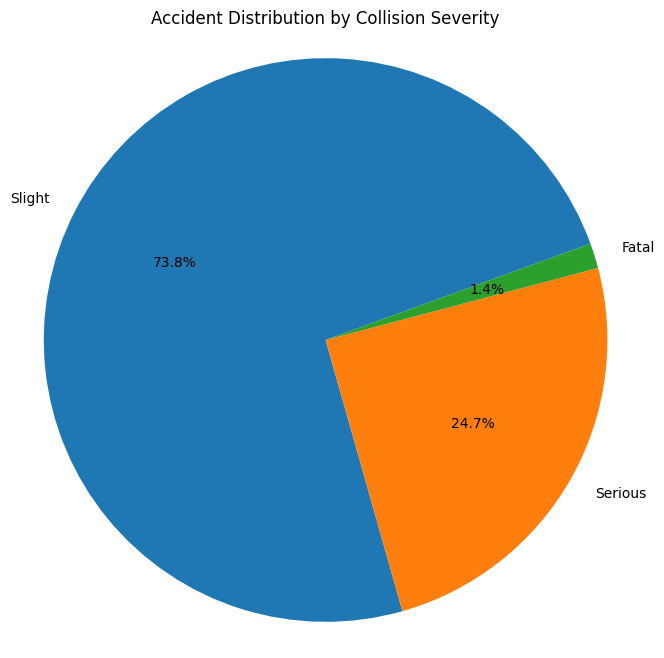

In [92]:
counts = df['collision_severity'].value_counts()

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    counts,
    labels=["Slight","Serious","Fatal"],
    autopct='%1.1f%%',
    startangle=20
)

plt.title('Accident Distribution by Collision Severity')
plt.axis('equal')
plt.show()

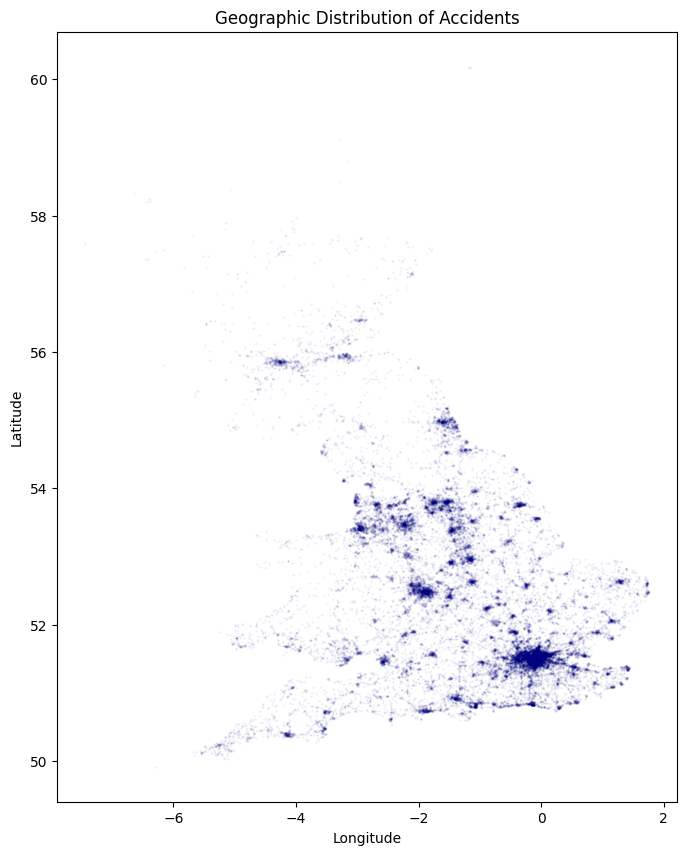

In [93]:
plt.figure(figsize=(8, 10))
plt.scatter(df['longitude'], df['latitude'], alpha=0.05, s=0.5, c='navy')
plt.title('Geographic Distribution of Accidents')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.savefig('geo_distribution.png', dpi=150)
plt.show()

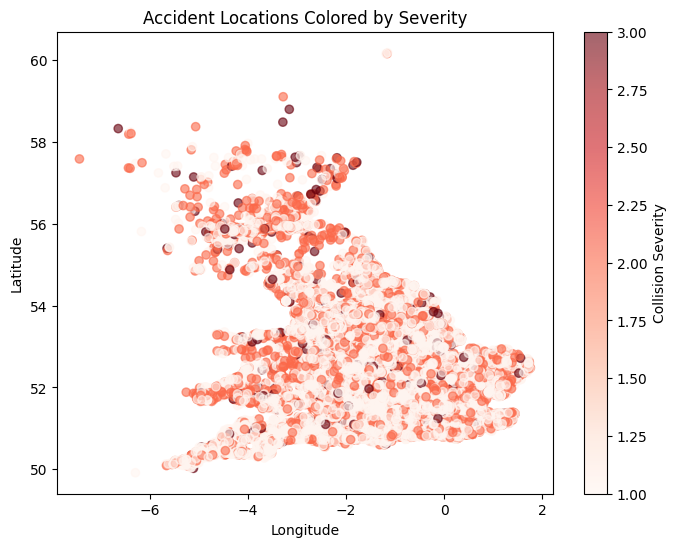

In [94]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['longitude'],
    df['latitude'],
    c=df['collision_severity'],
    cmap='Reds',   
    alpha=0.6
)

plt.colorbar(label='Collision Severity')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Accident Locations Colored by Severity')

plt.show()

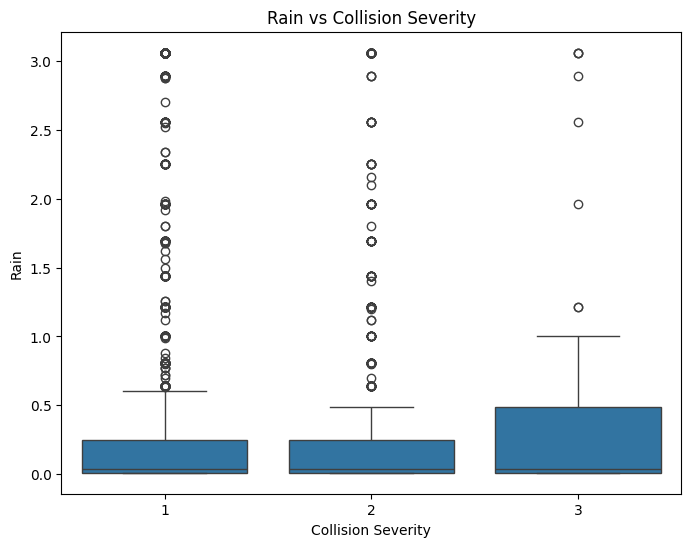

In [ ]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x='collision_severity',
    y='rain_intensity',
    data=df_scaled[df_scaled['rain_intensity'] > 0]
)

plt.title('Rain vs Collision Severity')
plt.xlabel('Collision Severity')
plt.ylabel('Rain')

plt.show()

# el range maben 25% le 75% lel severe accidents f3lan fe heavier rain
# mmkn ast3mel wx_rain aw rain_intensity kda kda wahda mnhom httshal 3shan strongly corrrelated

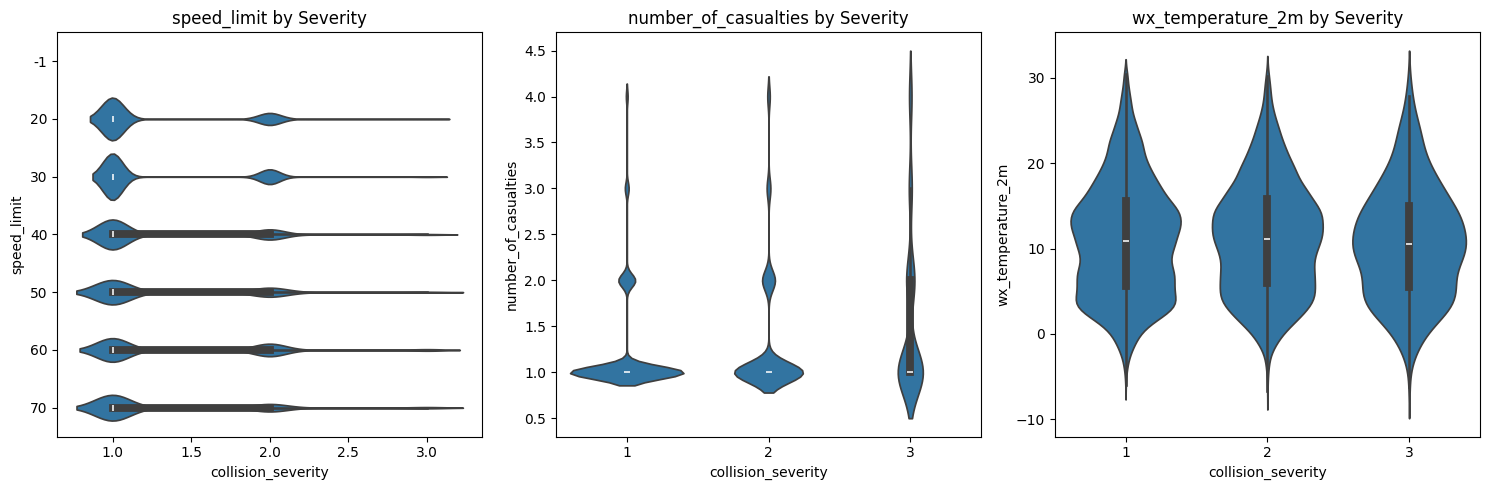

In [96]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ['speed_limit', 'number_of_casualties', 'wx_temperature_2m']):
    sns.violinplot(x='collision_severity', y=col, data=df, ax=ax)
    ax.set_title(f'{col} by Severity')
plt.tight_layout()
plt.show()

as the speed limit increases the severity increases

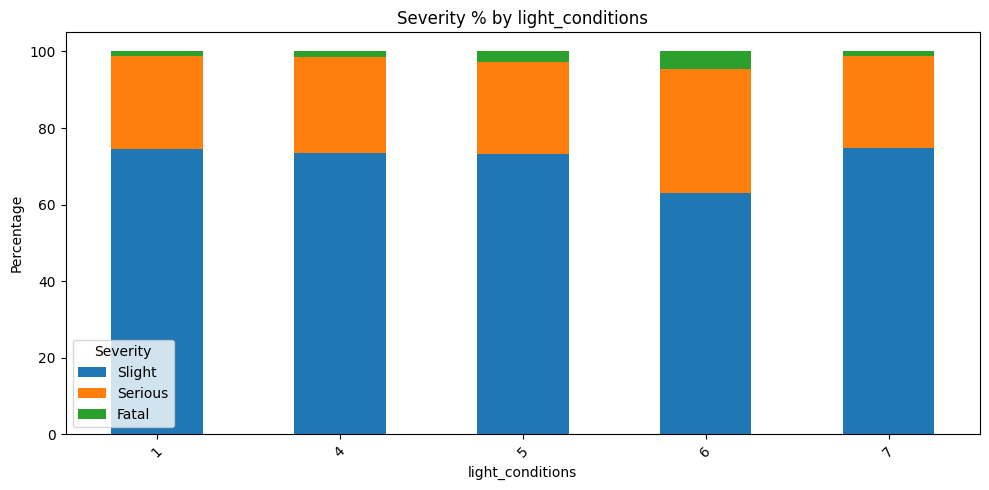

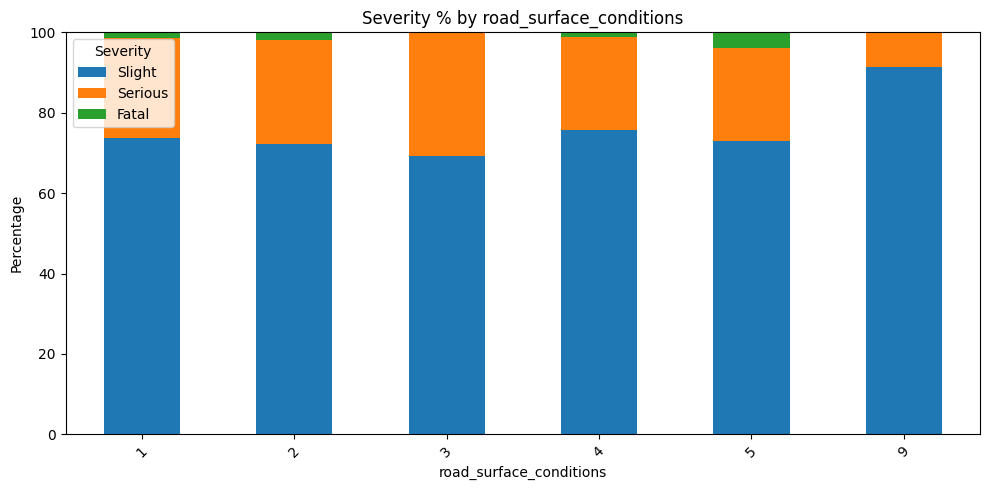

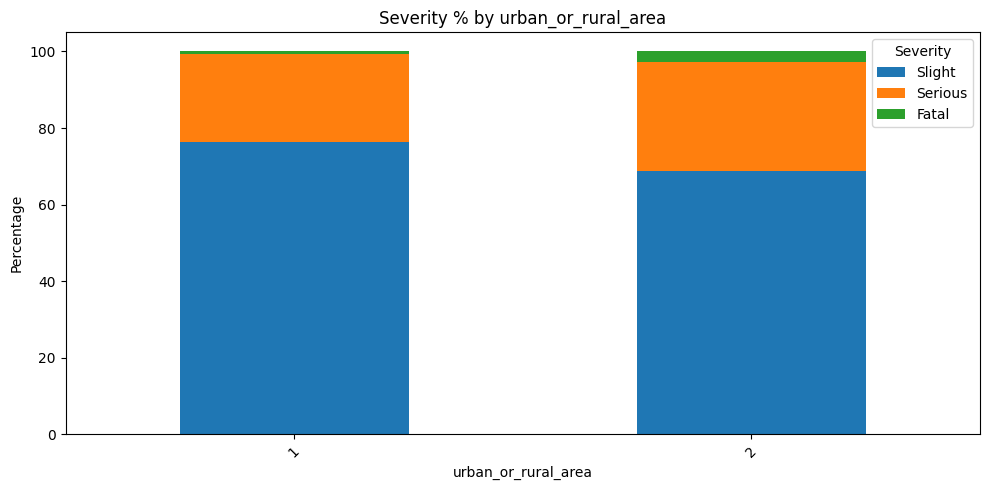

In [97]:
for cat in ['light_conditions', 'road_surface_conditions', 'urban_or_rural_area']:
    ct = pd.crosstab(df_scaled[cat], df_scaled['collision_severity'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, figsize=(10, 5))
    plt.title(f'Severity % by {cat}')
    plt.ylabel('Percentage')
    plt.xticks(rotation=45)
    plt.legend(title='Severity', labels=['Slight','Serious','Fatal'])
    plt.tight_layout()
    plt.show()

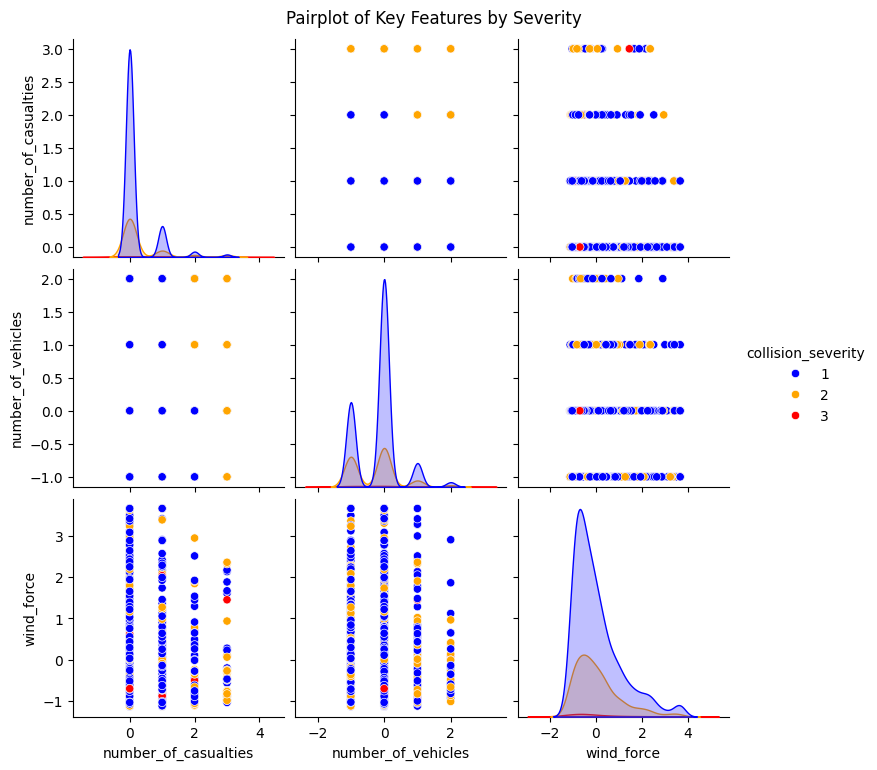

In [98]:
top_feats = ['speed_limit', 'number_of_casualties', 'number_of_vehicles',
             'wind_force', 'collision_severity']
sns.pairplot(df_scaled[top_feats].sample(2000), hue='collision_severity',
             palette={1:'blue', 2:'orange', 3:'red'})
plt.suptitle('Pairplot of Key Features by Severity', y=1.02)
plt.show()

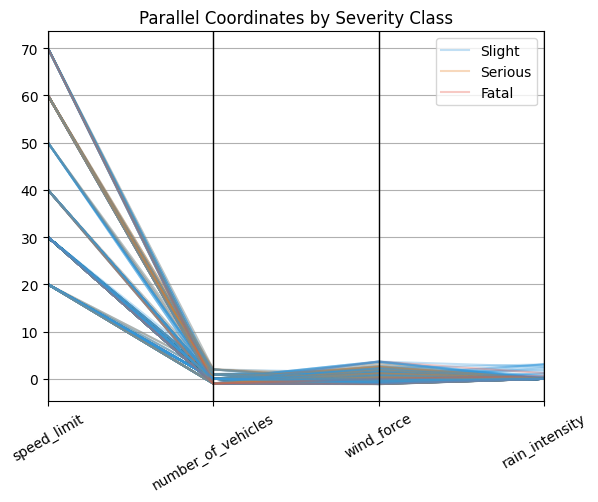

In [99]:
from pandas.plotting import parallel_coordinates

sample = df_scaled[['speed_limit','number_of_vehicles','wind_force',
             'rain_intensity','collision_severity']].sample(500).copy()
sample['collision_severity'] = sample['collision_severity'].map(
    {1:'Slight', 2:'Serious', 3:'Fatal'})

parallel_coordinates(sample, 'collision_severity',
                     color=['#3498db','#e67e22','#e74c3c'], alpha=0.3)
plt.title('Parallel Coordinates by Severity Class')
plt.xticks(rotation=30)
plt.show()

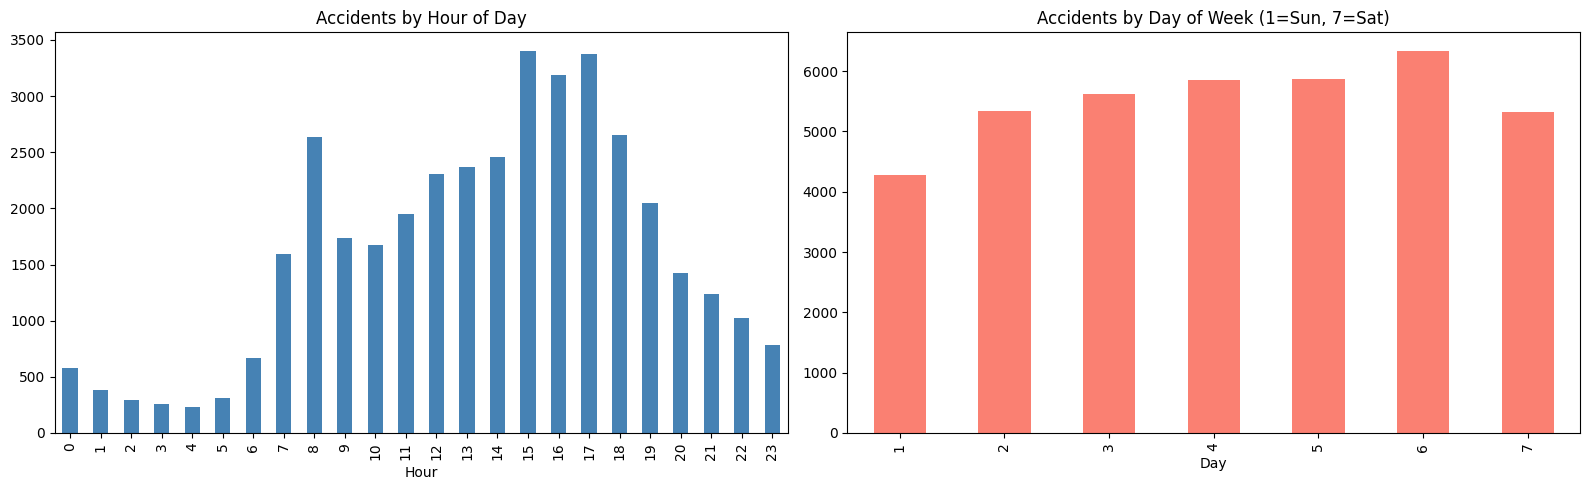

In [100]:
df_scaled['hour'] = pd.to_datetime(df_scaled['time'].astype(str), format='%H:%M:%S',
                             errors='coerce').dt.hour

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_scaled.groupby('hour').size().plot(ax=axes[0], kind='bar', color='steelblue')
axes[0].set_title('Accidents by Hour of Day')
axes[0].set_xlabel('Hour')

df_scaled.groupby('day_of_week').size().plot(ax=axes[1], kind='bar', color='salmon')
axes[1].set_title('Accidents by Day of Week (1=Sun, 7=Sat)')
axes[1].set_xlabel('Day')
plt.tight_layout()
plt.show()

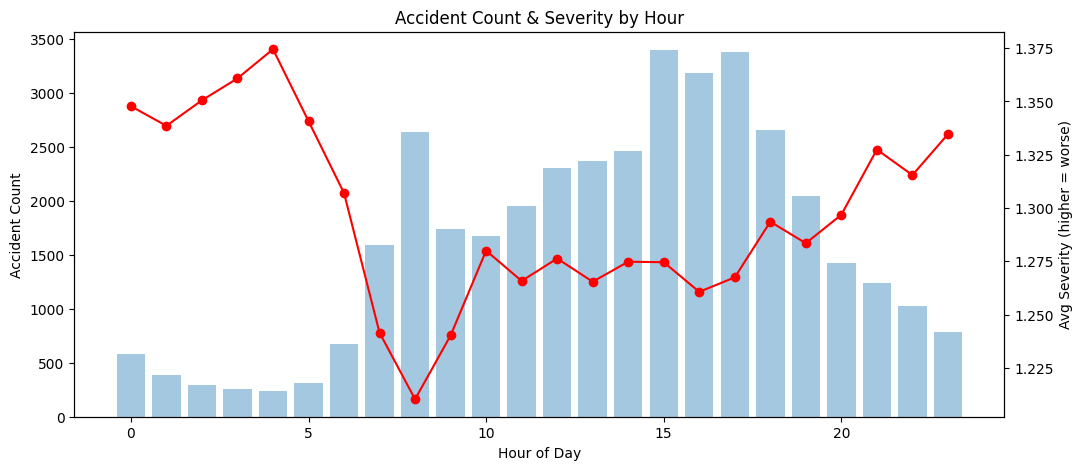

In [101]:
hourly = df_scaled.groupby('hour')['collision_severity'].agg(['mean','count'])
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(hourly.index, hourly['count'], alpha=0.4, label='Count')
ax2 = ax1.twinx()
ax2.plot(hourly.index, hourly['mean'], color='red', marker='o', label='Avg Severity')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Accident Count')
ax2.set_ylabel('Avg Severity (higher = worse)')
plt.title('Accident Count & Severity by Hour')
plt.show()

In [102]:
# plt.figure(figsize=(8,6))
# filtered_df = df[df['number_of_casualties'] < df['number_of_casualties'].quantile(0.99)]

# sns.kdeplot(
#     data=filtered_df,
#     x='number_of_vehicles',
#     y='number_of_casualties',
#     fill=True,
#     cmap='viridis',
#     thresh=0.05
# )

# plt.title('2D Density: Vehicles vs Casualties')
# plt.xlabel('Number of Vehicles')
# plt.ylabel('Number of Casualties')

# plt.show()

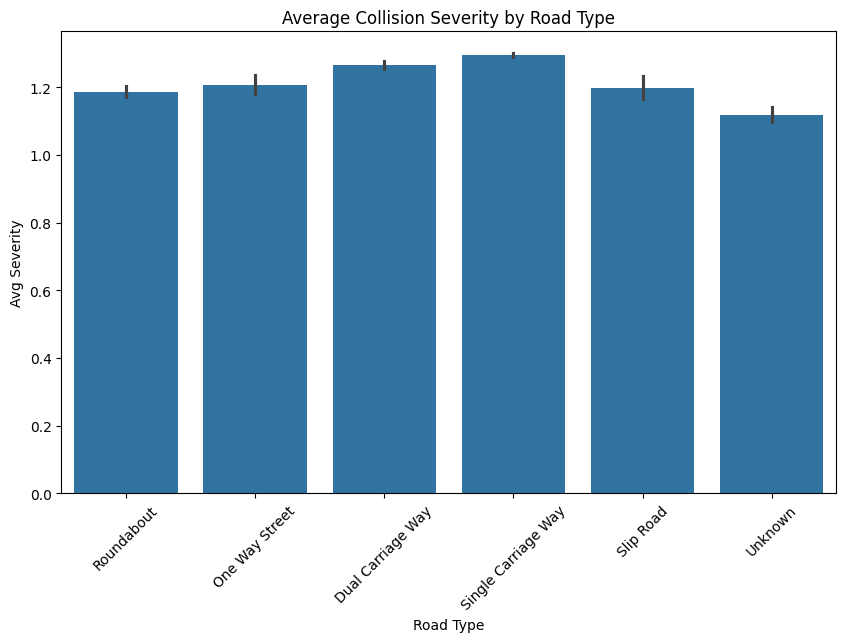

In [103]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='road_type',
    y='collision_severity',
    data=df_scaled,
    estimator='mean'
)

plt.xticks(
    ticks=range(len(df_scaled['road_type'].unique())),
    labels=["Roundabout", "One Way Street", "Dual Carriage Way", "Single Carriage Way", "Slip Road","Unknown"],
    rotation=45
)
plt.title('Average Collision Severity by Road Type')
plt.xlabel('Road Type')
plt.ylabel('Avg Severity')

plt.show()

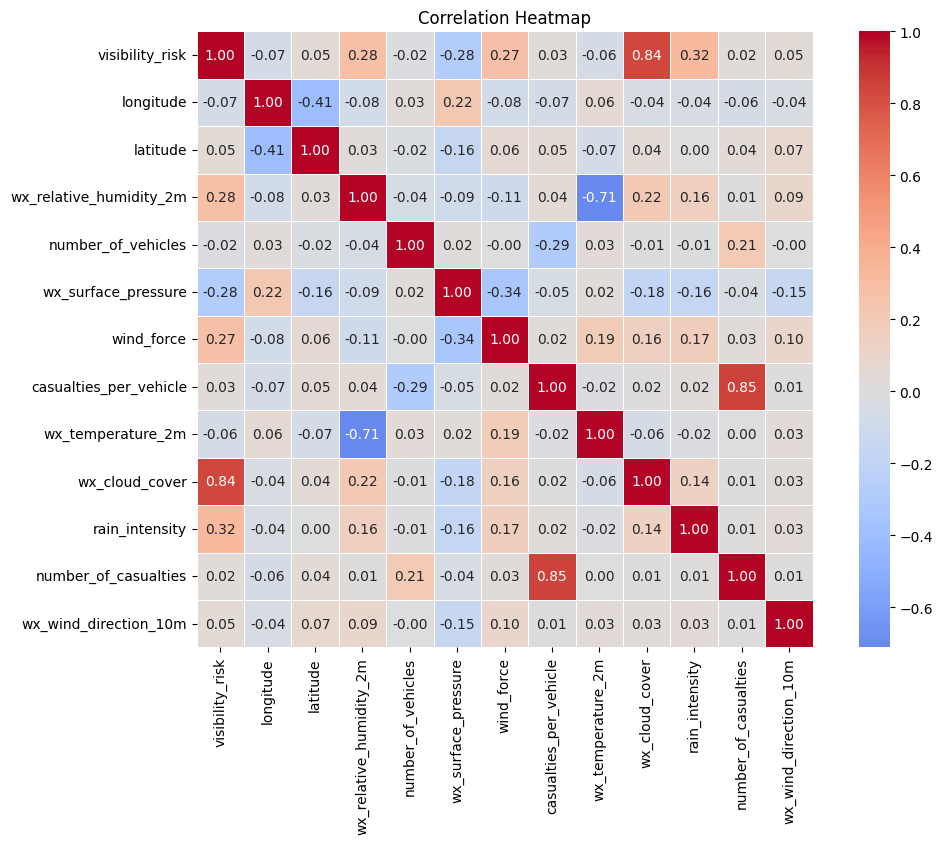

In [104]:
plt.figure(figsize=(12,8))

corr = df_scaled[numerical_cols].corr()

# sns.heatmap(
#     corr,
#     cmap='coolwarm',
#     center=0,
#     square=True
# )
sns.heatmap(
    corr,
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm',
    center=0, linewidths=0.5, square=True
)

plt.title('Correlation Heatmap')
plt.show()

In [107]:
# import pandas as pd
# import numpy as np
# import plotly.graph_objects as go
# from plotly.subplots import make_subplots
# import plotly.express as px


# df_plot = df.copy()  
# sev_map = {1: 'Slight', 2: 'Serious', 3: 'Fatal'}
# df_plot['sev_label'] = df_plot['collision_severity'].map(sev_map)

# df_plot['hour'] = pd.to_datetime(df_plot['time'].astype(str), format='%H:%M:%S', errors='coerce').dt.hour

# cats = ['light_conditions', 'road_surface_conditions', 'urban_or_rural_area']
# cts = {c: pd.crosstab(df_plot[c], df_plot['sev_label'], normalize='index') * 100 for c in cats}

# hourly = df_plot.groupby('hour')['collision_severity'].agg(['mean', 'count']).reset_index()

# df_geo = df_plot.sample(min(5000, len(df_plot)), random_state=42)
# df_violin = df_plot.sample(min(8000, len(df_plot)), random_state=42)

# fig = make_subplots(
#     rows=5, cols=3,
#     subplot_titles=(
#         'Severity Distribution', 'Geo Distribution (All)', 'Geo by Severity',
#         'Rain vs Severity', 'Speed Limit by Severity', 'Casualties by Severity',
#         'Temperature by Severity', 'Severity % by Light', 'Severity % by Road Surface',
#         'Severity % by Urban/Rural', 'Accidents by Hour', 'Accidents by Day of Week',
#         'Hourly Count vs Avg Severity', '', ''
#     ),
#     specs=[
#         [{"type": "pie"}, {"type": "scatter"}, {"type": "scatter"}],
#         [{"type": "box"}, {"type": "violin"}, {"type": "violin"}],
#         [{"type": "violin"}, {"type": "bar"}, {"type": "bar"}],
#         [{"type": "bar"}, {"type": "bar"}, {"type": "bar"}],
#         [{"type": "xy", "secondary_y": True, "colspan": 3}, None, None]
#     ],
#     vertical_spacing=0.08, horizontal_spacing=0.10
# )


# sev_colors = {'Slight':'#2ecc71', 'Serious':'#e67e22', 'Fatal':'#e74c3c'}

# counts = df_plot['sev_label'].value_counts()
# fig.add_trace(go.Pie(labels=counts.index, values=counts.values, hole=0.3, 
#                      marker_colors=[sev_colors[l] for l in counts.index], showlegend=False), row=1, col=1)

# fig.add_trace(go.Scatter(x=df_geo['longitude'], y=df_geo['latitude'], mode='markers',
#                          marker=dict(size=3, opacity=0.05, color='navy'), showlegend=False), row=1, col=2)

# fig.add_trace(go.Scatter(x=df_geo['longitude'], y=df_geo['latitude'], mode='markers',
#                          marker=dict(size=4, opacity=0.6, color=df_geo['collision_severity'],
#                                      colorscale='Reds', showscale=True, 
#                                      colorbar=dict(title='Severity', x=1.02)), showlegend=False), row=1, col=3)

# rain_df = df_plot[df_plot['rain_intensity'] > 0]
# fig.add_trace(go.Box(x=rain_df['sev_label'], y=rain_df['rain_intensity'], marker_color='#3498db', showlegend=False), row=2, col=1)
# fig.add_trace(go.Violin(x=df_violin['sev_label'], y=df_violin['speed_limit'], box_visible=True, meanline_visible=True, opacity=0.7, showlegend=False), row=2, col=2)
# fig.add_trace(go.Violin(x=df_violin['sev_label'], y=df_violin['number_of_casualties'], box_visible=True, meanline_visible=True, opacity=0.7, showlegend=False), row=2, col=3)

# fig.add_trace(go.Violin(x=df_violin['sev_label'], y=df_violin['wx_temperature_2m'], box_visible=True, meanline_visible=True, opacity=0.7, showlegend=False), row=3, col=1)

# legend_shown = False
# for i, cat in enumerate(cats[:2]):  
#     ct = cts[cat]
#     for sev in ct.columns:
#         fig.add_trace(go.Bar(x=ct.index.astype(str), y=ct[sev], name=sev, 
#                              marker_color=sev_colors[sev], showlegend=not legend_shown), row=3, col=i+2)
#     legend_shown = True

# ct = cts[cats[2]]
# for sev in ct.columns:
#     fig.add_trace(go.Bar(x=ct.index.astype(str), y=ct[sev], name=sev, 
#                          marker_color=sev_colors[sev], showlegend=False), row=4, col=1)

# hour_counts = df_plot.groupby('hour').size()
# day_counts = df_plot.groupby('day_of_week').size()
# fig.add_trace(go.Bar(x=hour_counts.index, y=hour_counts.values, marker_color='steelblue', name='By Hour', showlegend=False), row=4, col=2)
# fig.add_trace(go.Bar(x=day_counts.index, y=day_counts.values, marker_color='salmon', name='By Day', showlegend=False), row=4, col=3)

# fig.add_trace(go.Bar(x=hourly['hour'], y=hourly['count'], marker_color='rgba(0,0,255,0.4)', name='Count', showlegend=False), row=5, col=1)
# fig.add_trace(go.Scatter(x=hourly['hour'], y=hourly['mean'], mode='lines+markers', 
#                          line=dict(color='red', width=2), marker=dict(size=6), name='Avg Severity', showlegend=False), 
#               row=5, col=1, secondary_y=True)

# fig.update_layout(
#     height=1600, width=1200,
#     title_text="EDA Dashboard: Collision Severity Analysis",
#     title_x=0.5, title_font_size=22,
#     barmode='stack',
#     template="plotly_white",
#     legend=dict(orientation="h", yanchor="top", y=-0.12, xanchor="center", x=0.5, font_size=12)
# )

# # Axis labels
# axis_updates = [
#     (1,2,"Longitude","Latitude"), (1,3,"Longitude","Latitude"),
#     (2,1,"Severity","Rain Intensity"), (2,2,"Severity","Speed Limit"), (2,3,"Severity","Casualties"),
#     (3,1,"Severity","Temperature (2m)"), (3,2,"Condition","% of Accidents"), (3,3,"Condition","% of Accidents"),
#     (4,1,"Area Type","% of Accidents"), (4,2,"Hour of Day","Count"), (4,3,"Day of Week (1=Sun)","Count"),
#     (5,1,"Hour of Day","Count")
# ]
# for r, c, xlbl, ylbl in axis_updates:
#     fig.update_xaxes(title_text=xlbl, row=r, col=c)
#     fig.update_yaxes(title_text=ylbl, row=r, col=c)
# fig.update_yaxes(title_text="Avg Severity (higher=worse)", secondary_y=True, row=5, col=1)

# for r, c in [(3,2), (3,3), (4,1), (4,2), (4,3)]:
#     fig.update_xaxes(tickangle=-45, row=r, col=c)

# fig.show()

# fig.write_html("eda_dashboard.html")

# top_feats = ['speed_limit', 'number_of_casualties', 'number_of_vehicles', 'collision_severity']
# df_pair = df_plot[top_feats].sample(min(2000, len(df_plot)), random_state=42)
# df_pair['sev_label'] = df_pair['collision_severity'].map(sev_map)

# px.scatter_matrix(df_pair, dimensions=top_feats[:-1], color='sev_label',
#                   color_discrete_map=sev_colors, title="Pairplot of Key Features by Severity",
#                   width=1200, height=600).show()

# df_par = df_plot[['speed_limit','number_of_vehicles','collision_severity']].sample(500, random_state=42).copy()
# df_par['sev_label'] = df_par['collision_severity'].map(sev_map)

# # px.parallel_coordinates(df_par, color='collision_severity', dimensions=['speed_limit','number_of_vehicles','rain_intensity','wind_force'],
# #                         color_continuous_scale=['#3498db','#e67e22','#e74c3c'], title="Parallel Coordinates by Severity",
# #                         width=1200, height=500).show()

# Modeling

In [108]:
X_train = df_.drop(columns=[target_col])
y_train = df_[target_col]

## training random forest classifier to get baseline results  
### we chose RF because our data has so many categorical features, which RF should theoticlly excel in it

Accuracy : 0.732545045045045

Classification Report:
               precision    recall  f1-score   support

           1       0.74      0.98      0.84      5211
           2       0.46      0.05      0.10      1802
           3       0.00      0.00      0.00        91

    accuracy                           0.73      7104
   macro avg       0.40      0.34      0.31      7104
weighted avg       0.66      0.73      0.64      7104

Confusion Matrix:
 [[5108  103    0]
 [1706   96    0]
 [  83    8    0]]

Detected classes: [1 2 3] (count: 3)
ROC-AUC (OvR, weighted) : 0.6424939682708115

Top 10 Features:
latitude                                         0.066322
longitude                                        0.059227
wx_wind_direction_10m                            0.053048
wx_relative_humidity_2m                          0.052560
wx_temperature_2m                                0.051745
wx_surface_pressure                              0.051133
wind_force                                

c:\Users\Kareem\Documents\school\4th year - 2nd term\Data science\project\cookie\collision-severity-predictor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kareem\Documents\school\4th year - 2nd term\Data science\project\cookie\collision-severity-predictor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kareem\Documents\school\4th year - 2nd term\Data science\project\cookie\collision-severity-predictor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1

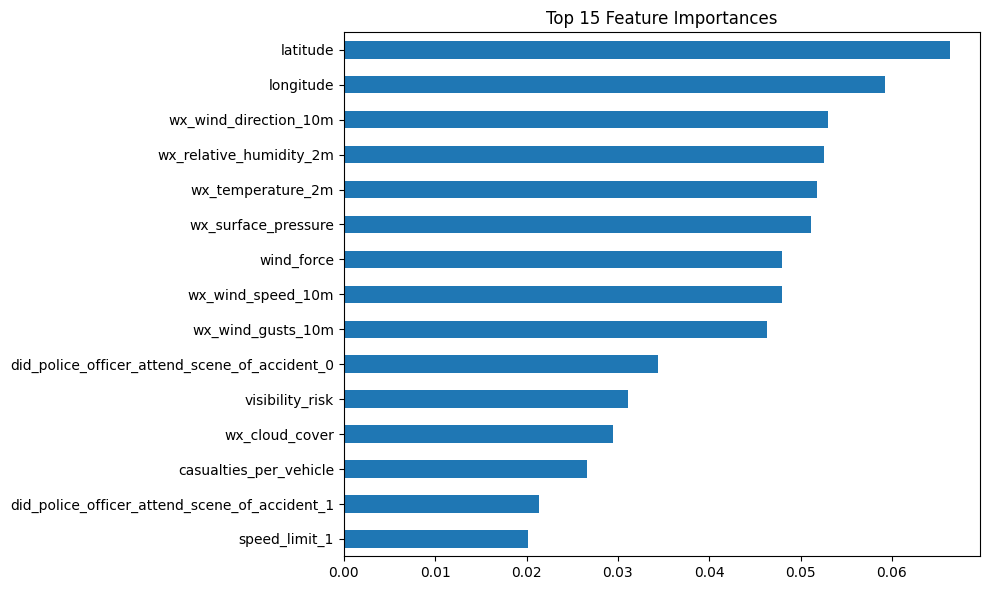

In [109]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, 
    confusion_matrix, roc_auc_score
)
import pandas as pd
import matplotlib.pyplot as plt

# ============================================
# 1. TRAIN
# ============================================
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# ============================================
# 2. PREDICT
# ============================================
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)  # shape: (n_samples, n_classes)

# ============================================
# 3. EVALUATE
# ============================================
print("Accuracy :", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# --- ROC-AUC: handle multiclass vs binary ---
n_classes = len(rf.classes_)
print(f"\nDetected classes: {rf.classes_} (count: {n_classes})")

if n_classes == 2:
    # Binary: use probability of the positive class (index 1)
    roc = roc_auc_score(y_test, y_proba[:, 1])
    print("ROC-AUC  :", roc)
else:
    # Multiclass: use OvR (One-vs-Rest) with full probability matrix
    roc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
    print("ROC-AUC (OvR, weighted) :", roc)

# ============================================
# 4. FEATURE IMPORTANCE
# ============================================
# FIX: use X_train.columns (not X_train_processed) since you fitted on X_train
importances = pd.Series(
    rf.feature_importances_, 
    index=X_train.columns          # ← must match what you fitted on
).sort_values(ascending=False)

print("\nTop 10 Features:")
print(importances.head(10))

plt.figure(figsize=(10, 6))
importances.head(15).plot(kind='barh')
plt.title("Top 15 Feature Importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [114]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

resampling = Pipeline([
    ('under', RandomUnderSampler(sampling_strategy={1: 20000}, random_state=42)),
    ('smote', SMOTE(sampling_strategy={2: 10000, 3: 4000}, random_state=42))
])

X_train_res, y_train_res = resampling.fit_resample(X_train, y_train)

print("\nSMOTE-ENN:")
print(pd.Series(y_train_res).value_counts().sort_index())


SMOTE-ENN:
collision_severity
1    20000
2    10000
3     4000
Name: count, dtype: int64


Accuracy : 0.7028434684684685

Classification Report:
               precision    recall  f1-score   support

           1       0.76      0.89      0.82      5211
           2       0.38      0.21      0.27      1802
           3       0.00      0.00      0.00        91

    accuracy                           0.70      7104
   macro avg       0.38      0.36      0.36      7104
weighted avg       0.65      0.70      0.67      7104

Confusion Matrix:
 [[4620  580   11]
 [1422  373    7]
 [  64   27    0]]

Detected classes: [1 2 3] (count: 3)
ROC-AUC (OvR, weighted) : 0.6431340032862677

Top 10 Features:
latitude                   0.054085
longitude                  0.045580
casualties_per_vehicle     0.044912
wx_wind_direction_10m      0.040351
wx_relative_humidity_2m    0.038668
wx_surface_pressure        0.038472
wx_temperature_2m          0.038115
wx_wind_speed_10m          0.036184
wind_force                 0.036160
speed_limit_1              0.035612
dtype: float64


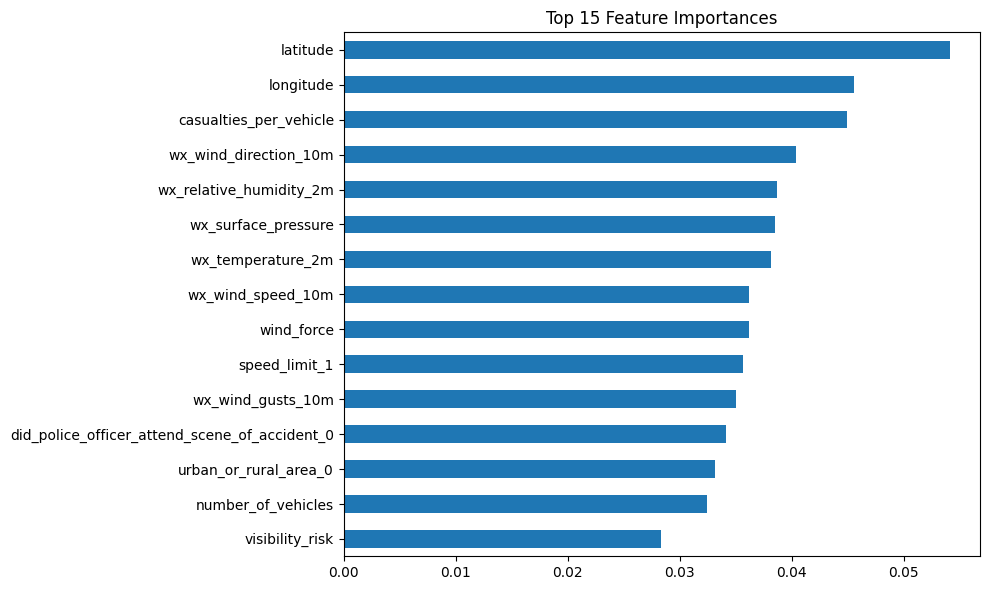

In [115]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, 
    confusion_matrix, roc_auc_score
)
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.utils.class_weight import compute_class_weight

# ============================================
# 1. TRAIN
# ============================================

classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))
# print(class_weights)  # e.g., {1: 0.4, 2: 1.9, 3: 25.0}

# Or manually boost the minority even more
class_weights = {1: 1.0, 2: 5.0, 3: 50.0}  # tune these
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_res, y_train_res)

# ============================================
# 2. PREDICT
# ============================================
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)  # shape: (n_samples, n_classes)

# ============================================
# 3. EVALUATE
# ============================================
print("Accuracy :", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# --- ROC-AUC: handle multiclass vs binary ---
n_classes = len(rf.classes_)
print(f"\nDetected classes: {rf.classes_} (count: {n_classes})")

if n_classes == 2:
    # Binary: use probability of the positive class (index 1)
    roc = roc_auc_score(y_test, y_proba[:, 1])
    print("ROC-AUC  :", roc)
else:
    # Multiclass: use OvR (One-vs-Rest) with full probability matrix
    roc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
    print("ROC-AUC (OvR, weighted) :", roc)

# ============================================
# 4. FEATURE IMPORTANCE
# ============================================
# FIX: use X_train.columns (not X_train_processed) since you fitted on X_train
importances = pd.Series(
    rf.feature_importances_, 
    index=X_train_res.columns          # ← must match what you fitted on
).sort_values(ascending=False)

print("\nTop 10 Features:")
print(importances.head(10))

plt.figure(figsize=(10, 6))
importances.head(15).plot(kind='barh')
plt.title("Top 15 Feature Importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Accuracy : 0.5892454954954955

Classification Report:
               precision    recall  f1-score   support

           1       0.80      0.61      0.69      5211
           2       0.33      0.55      0.41      1802
           3       0.04      0.02      0.03        91

    accuracy                           0.59      7104
   macro avg       0.39      0.40      0.38      7104
weighted avg       0.67      0.59      0.61      7104

Confusion Matrix:
 [[3185 2004   22]
 [ 778  999   25]
 [  25   64    2]]
ROC-AUC (OvR, weighted) : 0.6380124741494235

Top 10 Features:
did_police_officer_attend_scene_of_accident_0    0.107594
speed_limit_1                                    0.101106
urban_or_rural_area_1                            0.044974
urban_or_rural_area_0                            0.042668
first_road_class_2                               0.028204
speed_limit_2                                    0.024419
second_road_class_2                              0.023896
time_4               

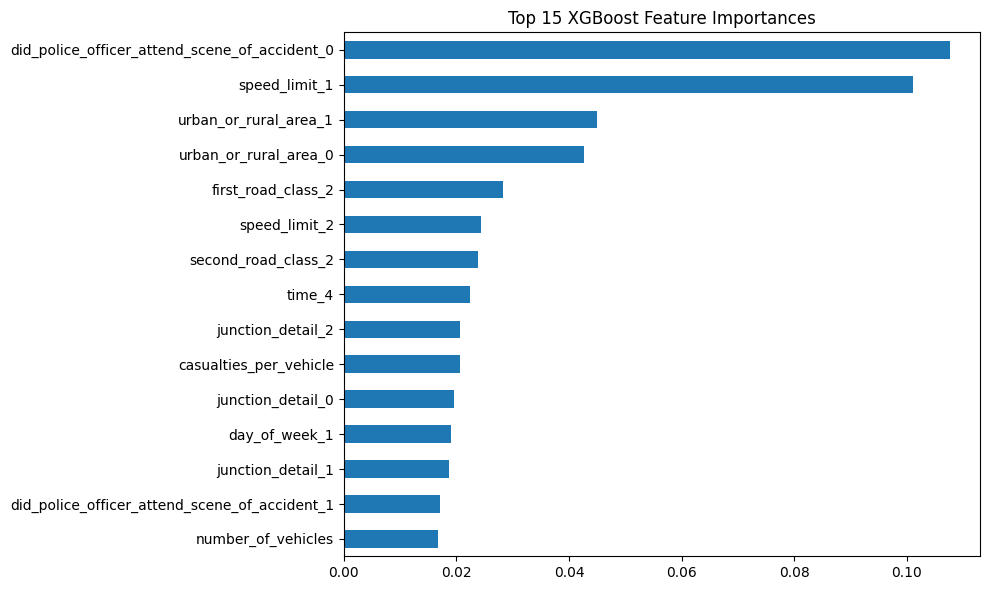

In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score, classification_report, 
    confusion_matrix, roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight

# ============================================
# 0. ADJUST LABELS FOR XGBOOST
# ============================================
# XGBoost multiclass expects labels starting at 0
y_train_xgb = y_train_res - 1
y_test_xgb = y_test - 1

# ============================================
# 1. TRAIN
# ============================================

classes = np.unique(y_train_xgb)  # now [0, 1, 2]
weights = compute_class_weight('balanced', classes=classes, y=y_train_xgb)
class_weights = dict(zip(classes, weights))

# Optional manual override (map to shifted classes 0,1,2)
# class_weights = {0: 1.0, 1: 5.0, 2: 50.0}

sample_weights = np.array([class_weights[y] for y in y_train_xgb])

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=1,
    objective='multi:softprob',
    num_class=3,              
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
)

xgb_model.fit(
    X_train_res, 
    y_train_xgb,          # ← use shifted labels
    sample_weight=sample_weights,
)

# ============================================
# 2. PREDICT (shift back to original labels)
# ============================================
y_pred_xgb = xgb_model.predict(X_test)        # returns [0, 1, 2]
y_pred = y_pred_xgb + 1                       # shift back to [1, 2, 3]

y_proba = xgb_model.predict_proba(X_test)     # probabilities stay aligned

# ============================================
# 3. EVALUATE
# ============================================
print("Accuracy :", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

n_classes = 3
if n_classes == 2:
    roc = roc_auc_score(y_test, y_proba[:, 1])
    print("ROC-AUC  :", roc)
else:
    roc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
    print("ROC-AUC (OvR, weighted) :", roc)

# ============================================
# 4. FEATURE IMPORTANCE
# ============================================
importances = pd.Series(
    xgb_model.feature_importances_, 
    index=X_train_res.columns
).sort_values(ascending=False)

print("\nTop 10 Features:")
print(importances.head(10))

plt.figure(figsize=(10, 6))
importances.head(15).plot(kind='barh')
plt.title("Top 15 XGBoost Feature Importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import (
    accuracy_score, classification_report, 
    confusion_matrix, roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight

# ============================================
# 0. ADJUST LABELS FOR CATBOOST
# ============================================
# CatBoost multiclass also expects zero-based labels
y_train_cb = y_train_res - 1
y_test_cb = y_test - 1

# ============================================
# 1. TRAIN
# ============================================

classes = np.unique(y_train_cb)  # [0, 1, 2]
weights = compute_class_weight('balanced', classes=classes, y=y_train_cb)
class_weights = dict(zip(classes, weights))

# Optional manual override
# class_weights = {0: 1.0, 1: 5.0, 2: 50.0}

cb_model = CatBoostClassifier(
    iterations=200,           # equivalent to n_estimators
    depth=6,                  # equivalent to max_depth
    learning_rate=0.1,
    l2_leaf_reg=3,            # L2 regularization
    random_seed=42,
    loss_function='MultiClass',
    eval_metric='MultiClass',
    class_weights=class_weights,   # ← pass directly here
    verbose=False,            # set to 50 to print every 50 iterations
    thread_count=-1,          # use all cores
    # task_type='GPU',        # uncomment if you have GPU
)

# Optional: if you have categorical columns, pass them via Pool
# cat_features = ['col_a', 'col_b']   # column names or integer indices
# train_pool = Pool(X_train_res, y_train_cb, cat_features=cat_features)
# cb_model.fit(train_pool)

cb_model.fit(X_train_res, y_train_cb)

# ============================================
# 2. PREDICT (shift back to original labels)
# ============================================
y_pred_cb = cb_model.predict(X_test).flatten()  # flatten in case shape is (n, 1)
y_pred = y_pred_cb + 1                          # [0,1,2] → [1,2,3]

y_proba = cb_model.predict_proba(X_test)

# ============================================
# 3. EVALUATE
# ============================================
print("Accuracy :", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

n_classes = len(np.unique(y_test_cb))
print(f"\nDetected classes: {np.unique(y_pred)} (count: {n_classes})")

if n_classes == 2:
    roc = roc_auc_score(y_test, y_proba[:, 1])
    print("ROC-AUC  :", roc)
else:
    roc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
    print("ROC-AUC (OvR, weighted) :", roc)

# ============================================
# 4. FEATURE IMPORTANCE
# ============================================
importances = pd.Series(
    cb_model.get_feature_importance(),
    index=X_train_res.columns
).sort_values(ascending=False)

print("\nTop 10 Features:")
print(importances.head(10))

plt.figure(figsize=(10, 6))
importances.head(15).plot(kind='barh')
plt.title("Top 15 CatBoost Feature Importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'catboost'

Accuracy : 0.7408097752925339

Classification Report:
               precision    recall  f1-score   support

           1       0.92      0.71      0.80     28523
           2       0.50      0.81      0.62      9548
           3       0.55      0.91      0.69       557

    accuracy                           0.74     38628
   macro avg       0.66      0.81      0.70     38628
weighted avg       0.81      0.74      0.76     38628

Confusion Matrix:
 [[20335  7872   316]
 [ 1679  7776    93]
 [    9    43   505]]

Detected classes: [1 2 3] (count: 3)
ROC-AUC (OvR, weighted) : 0.8490400665770518

Top 10 Features:
latitude                   1304
longitude                  1227
wx_wind_direction_10m      1219
wx_temperature_2m          1155
wx_surface_pressure        1131
wx_relative_humidity_2m    1042
wx_wind_speed_10m           849
wx_wind_gusts_10m           835
wind_force                  795
casualties_per_vehicle      513
dtype: int32


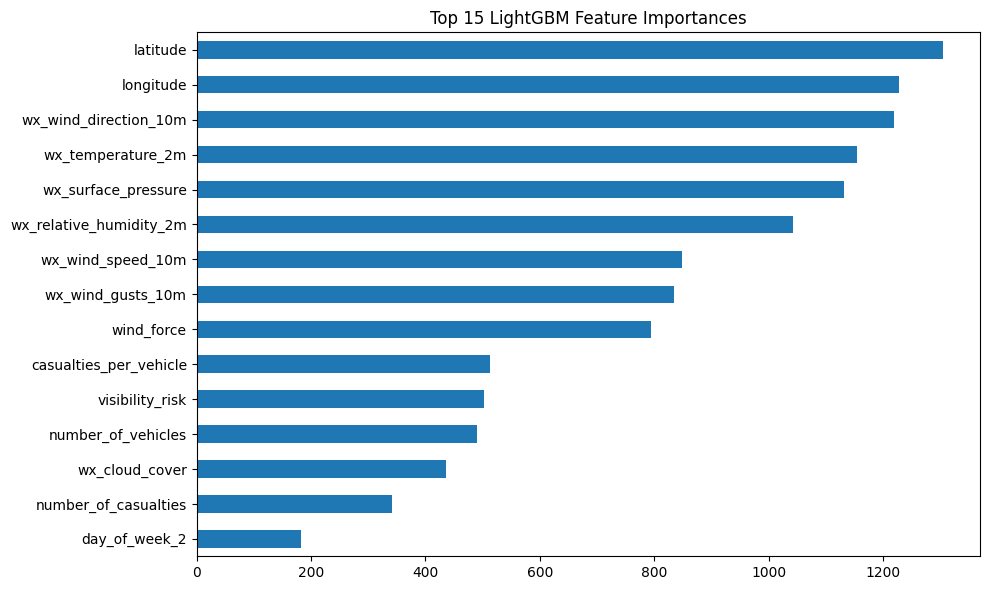

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import (
    accuracy_score, classification_report, 
    confusion_matrix, roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight

# ============================================
# 0. ADJUST LABELS FOR LIGHTGBM
# ============================================
# LightGBM multiclass expects zero-based contiguous labels
y_train_lgb = y_train_res - 1
y_test_lgb = y_test - 1

# ============================================
# 1. TRAIN
# ============================================

classes = np.unique(y_train_lgb)  # [0, 1, 2]
weights = compute_class_weight('balanced', classes=classes, y=y_train_lgb)
class_weights = dict(zip(classes, weights))

# Optional manual override
# class_weights = {0: 1.0, 1: 5.0, 2: 50.0}

lgb_model = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=-1,               # -1 means no limit
    num_leaves=31,              # LightGBM uses leaves instead of depth
    learning_rate=0.1,
    subsample=0.8,              # bagging_fraction alias
    colsample_bytree=0.8,       # feature_fraction alias
    min_child_samples=5,        # equivalent to min_samples_leaf
    min_child_weight=0.001,
    reg_alpha=0,                # L1
    reg_lambda=0,               # L2
    objective='multiclass',
    num_class=3,                # 3 classes: 0, 1, 2
    class_weight=class_weights, # ← pass dict here (sklearn API)
    random_state=42,
    n_jobs=-1,
    verbosity=-1,               # suppress training logs
)

lgb_model.fit(X_train_res, y_train_lgb)

# ============================================
# 2. PREDICT (shift back to original labels)
# ============================================
y_pred_lgb = lgb_model.predict(X_test)   # returns [0, 1, 2]
y_pred = y_pred_lgb + 1                  # shift back to [1, 2, 3]

y_proba = lgb_model.predict_proba(X_test)

# ============================================
# 3. EVALUATE
# ============================================
print("Accuracy :", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

n_classes = len(np.unique(y_test_lgb))
print(f"\nDetected classes: {np.unique(y_pred)} (count: {n_classes})")

if n_classes == 2:
    roc = roc_auc_score(y_test, y_proba[:, 1])
    print("ROC-AUC  :", roc)
else:
    roc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
    print("ROC-AUC (OvR, weighted) :", roc)

# ============================================
# 4. FEATURE IMPORTANCE
# ============================================
importances = pd.Series(
    lgb_model.feature_importances_, 
    index=X_train_res.columns
).sort_values(ascending=False)

print("\nTop 10 Features:")
print(importances.head(10))

plt.figure(figsize=(10, 6))
importances.head(15).plot(kind='barh')
plt.title("Top 15 LightGBM Feature Importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# --- Alternative: split-based importance ---
# importances_split = pd.Series(
#     lgb_model.booster_.feature_importance(importance_type='split'),
#     index=X_train_res.columns
# ).sort_values(ascending=False)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    accuracy_score, classification_report, 
    confusion_matrix, roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.inspection import permutation_importance

# ============================================
# 0. DEVICE & LABEL SHIFT
# ============================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

y_train_nn = y_train_res - 1
y_test_nn = y_test - 1

# ============================================
# 1. HYPERPARAMETERS
# ============================================
INPUT_DIM = X_train_res.shape[1]
HIDDEN_DIM = 256           # increased for better capacity
NUM_CLASSES = 3
BATCH_SIZE = 64
EPOCHS = 150
LEARNING_RATE = 1e-3
PATIENCE = 15

# ============================================
# 2. DATA LOADERS  (FIX: .copy() for writable arrays)
# ============================================
X_train_t = torch.FloatTensor(np.array(X_train_res, copy=True)).to(device)
y_train_t = torch.LongTensor(np.array(y_train_nn, copy=True)).to(device)
X_test_t = torch.FloatTensor(np.array(X_test, copy=True)).to(device)
y_test_t = torch.LongTensor(np.array(y_test_nn, copy=True)).to(device)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# ============================================
# 3. CLASS WEIGHTS (boost minority heavily)
# ============================================
classes = np.unique(y_train_nn)
weights = compute_class_weight('balanced', classes=classes, y=y_train_nn)
class_weights = torch.FloatTensor(weights).to(device)

# Strong manual boost for class 3 (index 2) if balanced isn't enough
# class_weights = torch.FloatTensor([1.0, 5.0, 100.0]).to(device)

# ============================================
# 4. MODEL (deeper + dropout for regularization)
# ============================================
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, dropout=0.4):
        super(MLPClassifier, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim),
            nn.Dropout(dropout),
            
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim),
            nn.Dropout(dropout),
            
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.Dropout(dropout),
            
            nn.Linear(hidden_dim // 2, num_classes)
        )
    
    def forward(self, x):
        return self.net(x)

model = MLPClassifier(INPUT_DIM, HIDDEN_DIM, NUM_CLASSES, dropout=0.4).to(device)

# ============================================
# 5. LOSS, OPTIMIZER, SCHEDULER
# ============================================
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10
)

# ============================================
# 6. TRAINING LOOP
# ============================================
best_loss = float('inf')
patience_counter = 0
history = {'train_loss': [], 'train_acc': []}

model.train()
for epoch in range(EPOCHS):
    epoch_losses = []
    correct = 0
    total = 0
    
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        epoch_losses.append(loss.item())
        _, predicted = torch.max(outputs, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()
    
    avg_loss = np.mean(epoch_losses)
    acc = correct / total
    history['train_loss'].append(avg_loss)
    history['train_acc'].append(acc)
    
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step(avg_loss)
    new_lr = optimizer.param_groups[0]['lr']
    if new_lr != current_lr:
        print(f"  ↓ LR reduced: {current_lr:.6f} → {new_lr:.6f}")
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {avg_loss:.4f} | Acc: {acc:.4f} | LR: {new_lr:.6f}")
    
    if avg_loss < best_loss:
        best_loss = avg_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pt')
    else:
        patience_counter += 1
    
    if patience_counter >= PATIENCE:
        print(f"Early stopping at epoch {epoch+1}")
        break

model.load_state_dict(torch.load('best_model.pt'))
model.eval()

# ============================================
# 7. PREDICT
# ============================================
with torch.no_grad():
    test_outputs = model(X_test_t)
    y_proba = torch.softmax(test_outputs, dim=1).cpu().numpy()
    y_pred_nn = np.argmax(y_proba, axis=1)

y_pred = y_pred_nn + 1

# ============================================
# 8. EVALUATE
# ============================================
print("\nAccuracy :", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

roc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
print("ROC-AUC (OvR, weighted) :", roc)

# ============================================
# 9. FEATURE IMPORTANCE (FIX: add fit() method)
# ============================================
class SklearnWrapper:
    def __init__(self, model, device):
        self.model = model
        self.device = device
        self.classes_ = np.array([1, 2, 3])  # original labels
    
    # FIX: sklearn requires fit() to exist
    def fit(self, X, y):
        return self
    
    def predict(self, X):
        X_t = torch.FloatTensor(np.array(X, copy=True)).to(self.device)
        with torch.no_grad():
            out = self.model(X_t)
            return (torch.argmax(out, dim=1).cpu().numpy() + 1)
    
    def predict_proba(self, X):
        X_t = torch.FloatTensor(np.array(X, copy=True)).to(self.device)
        with torch.no_grad():
            out = self.model(X_t)
            return torch.softmax(out, dim=1).cpu().numpy()

wrapped = SklearnWrapper(model, device)
perm_importance = permutation_importance(
    wrapped, X_test, y_test, 
    scoring='accuracy', 
    n_repeats=10, 
    random_state=42,
    n_jobs=-1
)

importances = pd.Series(
    perm_importance.importances_mean,
    index=X_train_res.columns
).sort_values(ascending=False)

print("\nTop 10 Features (Permutation Importance):")
print(importances.head(10))

plt.figure(figsize=(10, 6))
importances.head(15).plot(kind='barh')
plt.title("Top 15 Neural Network Feature Importances (Permutation)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ============================================
# 10. TRAINING HISTORY
# ============================================
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history['train_loss'])
ax[0].set_title('Training Loss')
ax[0].set_xlabel('Epoch')
ax[1].plot(history['train_acc'])
ax[1].set_title('Training Accuracy')
ax[1].set_xlabel('Epoch')
plt.tight_layout()
plt.show()

Using device: cpu


C:\Users\Kareem\AppData\Local\Temp\ipykernel_21408\3345111686.py:37: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  y_train_t = torch.LongTensor(y_train_nn.values).to(device)


Epoch [10/100] Loss: 0.6268 | Acc: 0.6052 | LR: 0.001000
Epoch [20/100] Loss: 0.5998 | Acc: 0.6081 | LR: 0.001000
Epoch [30/100] Loss: 0.5782 | Acc: 0.6184 | LR: 0.001000
Epoch [40/100] Loss: 0.5741 | Acc: 0.6202 | LR: 0.001000
Epoch [50/100] Loss: 0.5614 | Acc: 0.6227 | LR: 0.001000
Epoch [60/100] Loss: 0.5540 | Acc: 0.6274 | LR: 0.001000
Epoch [70/100] Loss: 0.5501 | Acc: 0.6253 | LR: 0.001000
Epoch [80/100] Loss: 0.5448 | Acc: 0.6301 | LR: 0.001000
Epoch [90/100] Loss: 0.5357 | Acc: 0.6363 | LR: 0.001000
  ↓ LR reduced: 0.001000 → 0.000500
Epoch [100/100] Loss: 0.5164 | Acc: 0.6394 | LR: 0.000500

Accuracy : 0.5594031531531531

Classification Report:
               precision    recall  f1-score   support

           1       0.81      0.55      0.65      5211
           2       0.32      0.62      0.42      1802
           3       0.04      0.04      0.04        91

    accuracy                           0.56      7104
   macro avg       0.39      0.40      0.37      7104
weighted av

InvalidParameterError: The 'estimator' parameter of permutation_importance must be an object implementing 'fit'. Got <__main__.SklearnWrapper object at 0x0000029509AD7A70> instead.

## Using 2 layer approach (2 binary classifiers)

In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, precision_score, classification_report, confusion_matrix

# ============================================
# LEVEL 1: Train with LIGHT class weight
# ============================================
y_train_l1 = (y_train != 1).astype(int)
y_test_l1 = (y_test != 1).astype(int)

rf1 = RandomForestClassifier(
    n_estimators=300,
    max_depth=30,
    min_samples_leaf=5,
    class_weight='balanced',   # ~{0:1, 1:4.4} based on your actual ratio — much saner than 15x
    random_state=42,
    n_jobs=-1
)
rf1.fit(X_train, y_train_l1)

# ============================================
# THRESHOLD TUNING: Constrain majority recall
# ============================================
proba_l1 = rf1.predict_proba(X_test)[:, 1]

best_t = 0.5
best_min_recall = 0
best_maj_recall = 0

# We demand at least 85% majority recall (only 15% of Class 1 sent to RF2)
# and pick the threshold that maximizes minority recall under that constraint
for t in np.arange(0.01, 0.99, 0.01):
    pred = (proba_l1 >= t).astype(int)
    maj_recall = recall_score(y_test_l1, pred, pos_label=0)
    min_recall = recall_score(y_test_l1, pred, pos_label=1)
    
    if maj_recall >= 0.85:
        if min_recall > best_min_recall:
            best_min_recall = min_recall
            best_maj_recall = maj_recall
            best_t = t

print(f"Chosen threshold: {best_t:.2f}")
print(f"Majority recall: {best_maj_recall:.3f} (kept out of RF2)")
print(f"Minority recall: {best_min_recall:.3f} (sent to RF2)")

y_pred_l1 = (proba_l1 >= best_t).astype(int)
print("\n=== LEVEL 1 ===")
print(classification_report(y_test_l1, y_pred_l1, target_names=['Majority(1)', 'Minority(2+3)']))

# ============================================
# LEVEL 2: Class 2 vs 3 (unchanged logic)
# ============================================
mask_l2 = y_train != 1
X_train_l2 = X_train[mask_l2]
y_train_l2 = (y_train[mask_l2] == 3).astype(int)

rf2 = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf2.fit(X_train_l2, y_train_l2)

# ============================================
# CASCADE INFERENCE
# ============================================
y_final = np.ones(len(X_test), dtype=int)

minority_mask = (proba_l1 >= best_t)
if minority_mask.sum() > 0:
    X_test_minority = X_test[minority_mask]
    proba_l2 = rf2.predict_proba(X_test_minority)[:, 1]
    pred_l2 = (proba_l2 >= 0.5).astype(int)
    y_final[minority_mask] = np.where(pred_l2 == 1, 3, 2)

# ============================================
# EVALUATION
# ============================================
print("\n=== CASCADE FINAL ===")
print(classification_report(y_test, y_final, digits=3))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_final))

In [ ]:
print(y_test.value_counts().sort_index())

# Class Balancing

In [ ]:
df_.columns

In [ ]:
print(df_['collision_severity'].value_counts().sort_index())

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

X = df_.drop('collision_severity', axis=1)
y = df_['collision_severity']

print("Original distribution:")
print(y.value_counts().sort_index())

rus = RandomUnderSampler(
    sampling_strategy={
        1: 17810,   
        2: 5962,  
        3: 556       #abosamra changed this from 695
    },
    random_state=42
)

X, y = rus.fit_resample(X, y)

print("\nAfter undersampling:")
print(pd.Series(y).value_counts().sort_index())

In [ ]:
from imblearn.under_sampling import TomekLinks



print("Original class distribution:")
print(y.value_counts().sort_index())

X_clean, y_clean = X, y

for i in range(5):
    tl = TomekLinks()
    X_clean, y_clean = tl.fit_resample(X_clean, y_clean)

print("\nAfter Tomek:")
print(pd.Series(y_clean).value_counts().sort_index())

In [ ]:
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from imblearn.combine import SMOTEENN
import pandas as pd

print("\nAfter Tomek:")
print(pd.Series(y_clean).value_counts().sort_index())



smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_clean, y_clean)

print("\nSMOTE:")
print(pd.Series(y_smote).value_counts().sort_index())


adasyn = ADASYN(random_state=42)
X_adasyn, y_adasyn = adasyn.fit_resample(X_clean, y_clean)

print("\nADASYN:")
print(pd.Series(y_adasyn).value_counts().sort_index())



bsmote = BorderlineSMOTE(random_state=42, kind='borderline-1')
X_bsmote, y_bsmote = bsmote.fit_resample(X_clean, y_clean)

print("\nBorderline-SMOTE:")
print(pd.Series(y_bsmote).value_counts().sort_index())


sme = SMOTEENN(random_state=42)
X_sme, y_sme = sme.fit_resample(X_clean, y_clean)

print("\nSMOTE-ENN:")
print(pd.Series(y_sme).value_counts().sort_index())

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score, balanced_accuracy_score

from imblearn.under_sampling import TomekLinks
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from imblearn.combine import SMOTEENN


# ============================================================
# 1. SPLIT FIRST (NO LEAKAGE)
# ============================================================


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train distribution:")
print(y_train.value_counts().sort_index())

print("\nTest distribution:")
print(y_test.value_counts().sort_index())


# ============================================================
# 2. SCALE FEATURES (IMPORTANT FOR LOGISTIC + SMOTE)
# ============================================================

scaler = StandardScaler()

X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test  = pd.DataFrame(scaler.transform(X_test), columns=X.columns)


# ============================================================
# 3. OPTIONAL: TOMEK ON TRAIN ONLY
# ============================================================

tl = TomekLinks()
X_train, y_train = tl.fit_resample(X_train, y_train)

print("\nAfter Tomek (train only):")
print(pd.Series(y_train).value_counts().sort_index())


# ============================================================
# 4. MODEL TRAINING FUNCTION
# ============================================================

def train_and_eval(name, X_tr, y_tr):
    model = LogisticRegression(max_iter=1000, multi_class='auto')
    model.fit(X_tr, y_tr)

    preds = model.predict(X_test)

    return {
        "method": name,
        "accuracy": accuracy_score(y_test, preds),
        "balanced_acc": balanced_accuracy_score(y_test, preds),
        "f1_weighted": f1_score(y_test, preds, average='weighted')
    }


# ============================================================
# 5. RESAMPLING METHODS
# ============================================================

results = []

# ---------------- SMOTE ----------------
smote = SMOTE(random_state=42)
X_s, y_s = smote.fit_resample(X_train, y_train)
results.append(train_and_eval("SMOTE", X_s, y_s))

# ---------------- ADASYN ----------------
adasyn = ADASYN(random_state=42)
X_a, y_a = adasyn.fit_resample(X_train, y_train)
results.append(train_and_eval("ADASYN", X_a, y_a))

# ---------------- Borderline SMOTE ----------------
bsmote = BorderlineSMOTE(random_state=42)
X_b, y_b = bsmote.fit_resample(X_train, y_train)
results.append(train_and_eval("Borderline-SMOTE", X_b, y_b))

# ---------------- SMOTE-ENN ----------------
sme = SMOTEENN(random_state=42)
X_se, y_se = sme.fit_resample(X_train, y_train)
results.append(train_and_eval("SMOTE-ENN", X_se, y_se))


# ============================================================
# 6. RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(results)
print("\n=== MODEL COMPARISON ===")
print(results_df.sort_values(by="f1_weighted", ascending=False))